# C06 · Code walkthrough: electrical and thermal components

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). This notebook covers the Tier 15 electrical components (converters, cables, protection), the
Tier 19 thermal components (lumped thermal model, ram-air heat exchanger) and the thermal discipline layer
(`thermal/heat.py`), then how `examples/halo_sizing.py` and `performance/flight_point.py` use them.

| Module | Lines | What it holds |
|---|---|---|
| `powertrain/components/converters.py` | 123 | `ConverterLossModel`, `Inverter` (also the generator's active rectifier), `DcDcConverter`, their results and limits |
| `powertrain/components/cable.py` | 129 | conductor and insulation materials, Dakin partial-discharge model, `pressure_ratio`, `Cable` |
| `powertrain/components/protection.py` | 44 | `ProtectionUnit` (contactor + fuse per feeder), result and limits |
| `powertrain/components/thermal.py` | 71 | `LumpedThermalModel`: one temperature, closed-form response to a constant loss |
| `powertrain/components/heat_exchanger.py` | 91 | `RamAirHeatExchanger`: air flow, pressure drop, cooling drag or fan power, rating demand |
| `thermal/heat.py` | 143 | `HeatLoad`, `thermal_parameters` (C and R of a component), `evaluate_point_thermal`, `coolant_temperatures_C` |

**State of the baseline (v3.6).** Two switches decide what is live:

- `HaloAssumptions.electrical_layer = False` (`halo_sizing.py:251`). No inverters, feeder cables or feeder
  protection are in the topology. The converter models and `build_halo_electrical` are dormant in the baseline.
- `HaloAssumptions.redundancy = True` (`:375`). `build_halo_redundancy` uses `ProtectionUnit` for the two battery
  **string contactors** and `ProtectionUnit` + `Cable` for the **bus tie**. These are the only electrical components
  in the sized aircraft.
- `HaloAssumptions.thermal_model = True` (`:353`, plan 030). Motors, generators and the pack carry a
  `LumpedThermalModel`; one `RamAirHeatExchanger` is installed with its rating as a design variable.

The cell below greps the package for importers, so the "who imports it" column cannot drift.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

import re, subprocess
from dataclasses import replace
from examples.halo_sizing import (HaloRequirements, build_halo_aircraft, build_halo_redundancy, build_halo_electrical,
                                  bus_voltage_window, power_electric_rated_W)
from examples.xv15_hot_day import temperature_offset_K

ref, assumptions, requirements = baseline(), baseline_assumptions(), HaloRequirements()
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
powertrain = aircraft.powertrain
instances = powertrain.topology.instances
print("electrical_layer:", assumptions.electrical_layer, "| redundancy:", assumptions.redundancy,
      "| thermal_model:", assumptions.thermal_model)
print({name: (type(i.component).__name__, i.count) for name, i in instances.items()})
print("cooling:", type(powertrain.cooling.heat_exchanger).__name__, "excluded", powertrain.cooling.sources_excluded)

electrical_layer: False | redundancy: True | thermal_model: True
{'turboshaft': ('SimpleTurboshaft', 2), 'generator': ('Generator', 2), 'battery': ('EquivalentCircuitBattery', 1), 'motor': ('Motor', 4), 'gearbox': ('Gearbox', 2), 'propulsor': ('MomentumProfileRotor', 2), 'generator_gearbox': ('Gearbox', 2), 'protection_string': ('ProtectionUnit', 2), 'protection_bus_tie': ('ProtectionUnit', 1), 'cable_bus_tie': ('Cable', 1)}
cooling: RamAirHeatExchanger excluded ('gearbox', 'generator_gearbox')


In [2]:
modules = {"converters": "powertrain.components.converters", "cable": "powertrain.components.cable",
           "protection": "powertrain.components.protection", "thermal (component)": "powertrain.components.thermal",
           "heat_exchanger": "powertrain.components.heat_exchanger", "thermal/heat": "thermal.heat"}
short = {"converters": r"components\.converters|from \.components\.converters",
         "cable": r"components\.cable|from \.components\.cable",
         "protection": r"components\.protection|from \.components\.protection",
         "thermal (component)": r"components\.thermal import",
         "heat_exchanger": r"components\.heat_exchanger",
         "thermal/heat": r"thermal\.heat import"}
files = sorted(list((repo_root / "src").rglob("*.py")) + list((repo_root / "examples").glob("*.py")))
for label, pattern in short.items():
    users = sorted({str(f.relative_to(repo_root)) for f in files
                    if re.search(r"^\s*from .*(" + pattern + ")", f.read_text(), re.M)})
    print(f"{label:<20} imported by: {', '.join(users)}")

converters           imported by: examples/halo_sizing.py, src/aircraft_closure/powertrain/compatibility.py, src/aircraft_closure/powertrain/ports.py
cable                imported by: examples/halo_sizing.py, src/aircraft_closure/powertrain/compatibility.py, src/aircraft_closure/powertrain/ports.py
protection           imported by: examples/halo_sizing.py, src/aircraft_closure/powertrain/compatibility.py, src/aircraft_closure/powertrain/ports.py
thermal (component)  imported by: examples/halo_sizing.py
heat_exchanger       imported by: examples/halo_sizing.py
thermal/heat         imported by: examples/halo_sizing.py, src/aircraft_closure/mission/mission.py, src/aircraft_closure/performance/flight_point.py, src/aircraft_closure/trajectory/tiltrotor.py


What each module imports: `converters` and `thermal` only `aerosandbox.numpy`; `cable` and `heat_exchanger` also
`aerosandbox` (for `asb.Atmosphere`); `protection` nothing; `thermal/heat.py` imports `core.margins` and the two
battery classes (it must know how each battery defines its continuous rating). None of the component modules
import each other: the machines and batteries hold a `thermal_model` field but never import `LumpedThermalModel`.

---
## 1. `powertrain/components/converters.py`

In [3]:
show_source("src/aircraft_closure/powertrain/components/converters.py", 1, 36)

# src/aircraft_closure/powertrain/components/converters.py  lines 1-36
   1  """Power converters (Tier 15): the motor/generator inverter and an optional DC/DC converter.
   2  
   3  Loss model (`ConverterLossModel`): at the rated point (power P_r, DC voltage V_r) the loss is
   4  L_r = P_r (1 - eta_r) / eta_r, split into a fixed part (gate drive, control, capacitive), a switching part
   5  proportional to |P| (switching energy ~ V I per event, with I = P / V) and a conduction part proportional
   6  to I^2 = (P / V)^2:
   7  
   8      P_loss = L_r [f_0 + f_s |P| / P_r + f_c (P / P_r)^2 (V_r / V)^2],   f_0 = 1 - f_s - f_c.
   9  
  10  So efficiency is exactly eta_r at (P_r, V_r), peaks at |P| / P_r = sqrt(f_0 / f_c), and falls as the DC
  11  voltage sags (more current for the same power). |P| is smoothed (sqrt(P^2 + (eps P_r)^2)) so the model is
  12  differentiable through zero power. Defaults: 98.5 % at rated (SiC; NASA EAP converter goal 99 %, Jansen et
  13  al., AIAA 2017-470

**L1-14 docstring: the loss model.** At the rated point (power P_r, DC voltage V_r) the loss is fixed by the rated
efficiency, and split into three physical terms:

$$L_r = P_r \frac{1-\eta_r}{\eta_r}, \qquad P_{loss} = L_r\Big[f_0 + f_s \frac{|P|}{P_r} + f_c \Big(\frac{P}{P_r}\Big)^2\Big(\frac{V_r}{V}\Big)^2\Big], \qquad f_0 = 1 - f_s - f_c$$

- fixed part f_0 (gate drive, control, capacitor losses): present at any power;
- switching part proportional to |P|: energy per switching event scales with V I, and V I = P, so at a fixed
  switching frequency the switching loss is proportional to power and independent of V;
- conduction part proportional to I^2 = (P/V)^2: at the same power a sagging bus (lower V) means more current and
  more conduction loss. This is the only voltage dependence.

The rated efficiency is defined as output over input when motoring, η_r = P_r / (P_r + L_r), which inverts to the
L_r formula (L30). Efficiency P/(P + P_loss) peaks where the loss per watt is smallest: d/dP (P_loss/P) = 0 gives
f_0/P^2 = f_c/P_r^2 at V = V_r, so the peak is at |P|/P_r = sqrt(f_0/f_c). With the defaults f_0 = 0.1, f_c = 0.5
that is 0.447 of rated (plan 023: "peak efficiency is near 45 % load").

**L21-35 `ConverterLossModel`.**
- **L23-26** defaults: 98.5 % at rated (SiC, NASA EAP goal 99 %, Jansen et al. AIAA 2017-4701), split 0.5 / 0.4 /
  0.1 (assumed), rated at 800 V. The Halo overrides `voltage_rated_V` with the nominal pack voltage
  (`halo_sizing.py:527`).
- **L27** `fraction_power_smoothing = 1e-3`, typed `float` not `Any`: it is a numerical knob, never a design variable.
- **L30** L_r. **L31** f_0 computed, not stored, so the three fractions always sum to one.
- **L32** smoothed absolute value sqrt(P^2 + (1e-3 P_r)^2). |P| has a kink at P = 0, and a rectifier or a charging
  DC/DC crosses zero power in the optimizer's path. The smoothing adds at most 1e-3 P_r to |P| (at P = 0) and a
  relative 5e-7 at rated.
- **L33-35** the bracket. Note the conduction term uses the signed P squared and the switching term the smoothed |P|,
  so the loss is even in P: a rectifier (negative power) loses the same as an inverter at the same |P|.
- `power_rated_W` is an **argument**, not a field: the same loss model object is shared by both inverters
  (`halo_sizing.py:527-535`) which have different ratings.

**Run it**: the identities on numbers, and the efficiency map at three bus voltages of the Halo pack window
(210 cells: 525 V empty, 756 V nominal, 882 V full).

BusVoltageWindow(voltage_nominal_V=756.0, voltage_min_V=525.0, voltage_max_V=882.0, voltage_max_inverter_V=900.0)
L_r = 7614.2 W; efficiency at (P_r, V_r) = 0.9849999970
PASS  efficiency at (P_r, V_r) equals 98.5 % (smoothing error < 1e-8)
PASS  loss is even in power (rectifier = inverter)
PASS  standstill loss = fixed fraction x L_r (+ smoothing)


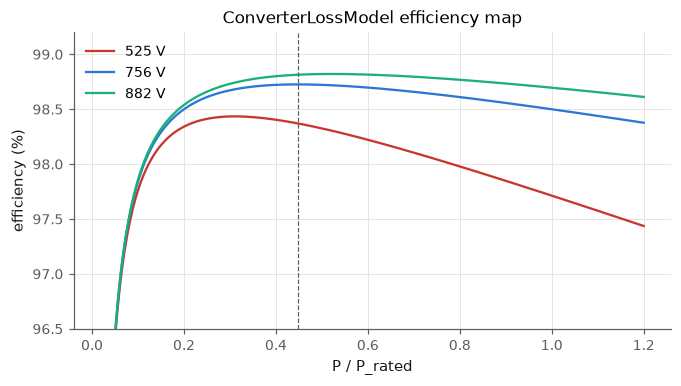

peak at nominal voltage: P/P_r = 0.446 (sqrt(f0/fc) = 0.447)
PASS  efficiency peaks at sqrt(f0/fc) of rated at V_r


In [4]:
from aircraft_closure.powertrain.components.converters import (ConverterLossModel, DcDcConverter, Inverter)
window = bus_voltage_window(assumptions)
print(window)
model = ConverterLossModel(voltage_rated_V=window.voltage_nominal_V)
P_r = 500e3
loss_rated_W = P_r * (1 - 0.985) / 0.985                               # L_r
eta_rated = P_r / (P_r + model.evaluate(P_r, window.voltage_nominal_V, P_r))
print(f"L_r = {loss_rated_W:.1f} W; efficiency at (P_r, V_r) = {eta_rated:.10f}")
check("efficiency at (P_r, V_r) equals 98.5 % (smoothing error < 1e-8)", abs(eta_rated - 0.985) < 1e-8)
check("loss is even in power (rectifier = inverter)",
      abs(model.evaluate(-0.3 * P_r, 700.0, P_r) - model.evaluate(0.3 * P_r, 700.0, P_r)) < 1e-9)
check("standstill loss = fixed fraction x L_r (+ smoothing)",
      abs(model.evaluate(0.0, 700.0, P_r) - loss_rated_W * (0.1 + 0.4 * 1e-3)) < 1e-6)

fractions = np.linspace(0.02, 1.2, 400)
fig, ax = plt.subplots(figsize=(7, 3.5))
for V, color in ((window.voltage_min_V, red), (window.voltage_nominal_V, blue), (window.voltage_max_V, aqua)):
    P = fractions * P_r
    eta = P / (P + model.evaluate(P, V, P_r))
    ax.plot(fractions, 100 * eta, color=color, label=f"{V:.0f} V")
    if V == window.voltage_nominal_V:
        peak = fractions[np.argmax(eta)]
ax.axvline(np.sqrt(0.1 / 0.5), color=ink_muted, lw=0.8, ls="--")
ax.set(xlabel="P / P_rated", ylabel="efficiency (%)", ylim=(96.5, 99.2), title="ConverterLossModel efficiency map")
ax.legend(); plt.show()
print(f"peak at nominal voltage: P/P_r = {peak:.3f} (sqrt(f0/fc) = {np.sqrt(0.2):.3f})")
check("efficiency peaks at sqrt(f0/fc) of rated at V_r", abs(peak - np.sqrt(0.2)) < 0.005)

The same peak, found symbolically: an `asb.Opti` maximizes P / (P + loss) over P. This is what happens inside a
sizing when the loss model is evaluated on an Opti variable; nothing in the model branches on the value of P.

In [5]:
opti = asb.Opti()
fraction = opti.variable(init_guess=0.9, lower_bound=0.05, upper_bound=1.5)
P = fraction * P_r
opti.maximize(P / (P + model.evaluate(P, window.voltage_nominal_V, P_r)))
sol = opti.solve(verbose=False)
print("optimal load fraction:", sol(fraction))
check("Opti finds the peak-efficiency load sqrt(0.2)", abs(sol(fraction) - np.sqrt(0.2)) < 1e-3)

optimal load fraction: 0.44721558381334997
PASS  Opti finds the peak-efficiency load sqrt(0.2)


In [6]:
show_source("src/aircraft_closure/powertrain/components/converters.py", 38, 78)

# src/aircraft_closure/powertrain/components/converters.py  lines 38-78
  38  @dataclass(frozen=True)
  39  class InverterResult:
  40      power_ac_W: Any          # positive: DC -> AC (motoring); negative: AC -> DC (active rectifier)
  41      power_dc_W: Any          # = power_ac_W + power_loss_W
  42      power_loss_W: Any
  43      current_dc_A: Any        # positive into the DC terminals
  44  
  45  
  46  @dataclass(frozen=True)
  47  class InverterLimits:
  48      power_rated_W: Any
  49      min_voltage_V: Any
  50      max_voltage_V: Any       # derated semiconductor blocking voltage
  51  
  52  
  53  @dataclass(frozen=True)
  54  class Inverter:
  55      """Three-phase two-level DC/AC converter, also used as the generator's active rectifier.
  56  
  57      Mass = rated AC power / specific power (default 20 kW/kg, assumed between the NASA 19 kW/kg goal and
  58      recent SiC demonstrators). The DC-link limit is the blocking voltage x a derating factor (0.75 for
  59 

**L38-43 `InverterResult`.** The sign convention is on the **AC side**: positive `power_ac_W` is DC to AC
(motoring); negative is AC to DC (the generator's active rectifier). `power_dc_W = power_ac_W + power_loss_W`
holds in both directions: motoring, the DC side supplies the AC power plus the loss; rectifying, the DC side
receives |P_ac| minus the loss (a less negative number). `current_dc_A` is positive into the DC terminals.

**L46-50 `InverterLimits`**: rated power, minimum DC voltage, maximum DC voltage (the derated blocking voltage).

**L53-78 `Inverter`.**
- **L57-59 docstring**: mass = rating / specific power, 20 kW/kg (between the NASA 19 kW/kg goal and SiC
  demonstrators). DC-link limit = blocking voltage x 0.75 (single-event burnout from cosmic rays at altitude):
  1,200 V devices give 900 V.
- **L61-66** fields; `loss_model` uses `field(default_factory=...)` because a dataclass default must not be a shared
  mutable instance (here it is frozen, but the factory is the rule).
- **L68-69 `get_mass`**: linear in the rating, so a symbolic rating gives a symbolic mass.
- **L71-73 `get_limits`**: the max voltage is computed (blocking x derating), not stored, so changing the device
  class changes the limit in one place.
- **L75-78 `evaluate(power_ac_W, voltage_dc_V)`**: one loss call, one power sum, one current. The DC current is
  P_dc / V_dc: no iteration.

The Halo would build one `Inverter` per machine type (`build_halo_electrical`, section 7) rated at
`power_electric_rated_W(machine)` = shaft rating / McDonald peak efficiency. With the layer off, the sized
aircraft has none; the run below builds them on the baseline machines as a what-if (the layer would also change
the machine mass model to bare machines, so this is not a sized result).

In [7]:
motor, generator, battery = (instances[n].component for n in ("motor", "generator", "battery"))
layer = build_halo_electrical(motor, generator, battery, ref.span_m, requirements,
                              replace(assumptions, electrical_layer=True))
inv = layer.inverter_motor
print(f"inverter_motor: rating {inv.power_rated_W/1e3:.1f} kW = motor {motor.power_rated_W/1e3:.1f} kW / "
      f"eta_peak {motor.loss_model.efficiency_peak:.4f}; mass {inv.get_mass():.2f} kg; limits {inv.get_limits()}")
motoring = inv.evaluate(0.6 * inv.power_rated_W, 800.0)
rectifying = layer.inverter_generator.evaluate(-0.6 * layer.inverter_generator.power_rated_W, 800.0)
print("motoring  :", {k: round(float(v), 1) for k, v in vars(motoring).items()})
print("rectifying:", {k: round(float(v), 1) for k, v in vars(rectifying).items()})
check("motoring: DC power = AC power + loss",
      abs(motoring.power_dc_W - motoring.power_ac_W - motoring.power_loss_W) < 1e-6)
check("rectifying: |DC power| = |AC power| - loss (DC side receives less)",
      abs(-rectifying.power_dc_W - (-rectifying.power_ac_W - rectifying.power_loss_W)) < 1e-6)
check("inverter max voltage = 1200 V x 0.75 = 900 V", abs(inv.get_limits().max_voltage_V - 900.0) < 1e-12)

inverter_motor: rating 549.8 kW = motor 527.8 kW / eta_peak 0.9600; mass 27.49 kg; limits InverterLimits(power_rated_W=549778.7143782137, min_voltage_V=472.5, max_voltage_V=900.0)
motoring  : {'power_ac_W': 329867.2, 'power_dc_W': 334059.6, 'power_loss_W': 4192.4, 'current_dc_A': 417.6}
rectifying: {'power_ac_W': -590625.0, 'power_dc_W': -583118.6, 'power_loss_W': 7506.4, 'current_dc_A': -728.9}
PASS  motoring: DC power = AC power + loss
PASS  rectifying: |DC power| = |AC power| - loss (DC side receives less)
PASS  inverter max voltage = 1200 V x 0.75 = 900 V


In [8]:
show_source("src/aircraft_closure/powertrain/components/converters.py", 81, 123)

# src/aircraft_closure/powertrain/components/converters.py  lines 81-123
  81  @dataclass(frozen=True)
  82  class DcDcConverterResult:
  83      power_input_W: Any       # positive: battery side -> bus side
  84      power_output_W: Any      # = power_input_W - power_loss_W
  85      power_loss_W: Any
  86      current_input_A: Any
  87      current_output_A: Any
  88  
  89  
  90  @dataclass(frozen=True)
  91  class DcDcConverterLimits:
  92      power_rated_W: Any
  93      min_voltage_input_V: Any
  94      max_voltage_input_V: Any
  95      voltage_output_V: Any
  96  
  97  
  98  @dataclass(frozen=True)
  99  class DcDcConverter:
 100      """Bidirectional DC/DC converter that regulates the bus at `voltage_output_V` (optional, off by default).
 101  
 102      Mass = rated power / specific power (12 kW/kg, assumed); losses as `ConverterLossModel` with the input
 103      (battery) voltage as the conduction voltage, 98 % at rated (assumed).
 104      """
 105      power_rated_W:

**L81-87 `DcDcConverterResult`**: sign convention on the **input** (battery) side: positive is battery to bus.
`power_output_W = power_input_W - power_loss_W`: the loss is subtracted on the output side, the opposite bookkeeping
to the inverter (where it is added on the input side). Both are "input = output + loss" for the forward direction.
Two currents: input at the battery voltage, output at the regulated bus voltage.

**L90-95 `DcDcConverterLimits`**: rating, input voltage window, the regulated output voltage.

**L98-123 `DcDcConverter`.** Optional, off by default (`dcdc_converter=False`, `halo_sizing.py:267`): it
regulates the bus at `voltage_output_V` and decouples it from the pack series count.
- **L105-110** 12 kW/kg (assumed), 98 % at rated (L110: a lambda default factory, so each converter gets its own
  loss model with `efficiency_rated=0.98`).
- **L119-123 `evaluate(power_input_W, voltage_input_V)`**: the conduction voltage is the **input** voltage
  (battery side, where the current is largest when the pack sags). The output current uses the fixed
  `voltage_output_V`: the output side is regulated by assumption.

Plan 023 enumerated bus voltages with and without the DC/DC: every DC/DC variant was 30-40 kg heavier than letting
the pack set the bus at the same voltage, which is why it stays off.

In [9]:
dcdc = DcDcConverter(power_rated_W=850e3, voltage_output_V=800.0)
result = dcdc.evaluate(600e3, 620.0)
print({k: round(float(v), 2) for k, v in vars(result).items()})
check("DC/DC: output = input - loss, output current at the regulated voltage",
      abs(result.power_output_W - (600e3 - result.power_loss_W)) < 1e-6
      and abs(result.current_output_A - result.power_output_W / 800.0) < 1e-9)
sagged, full = dcdc.evaluate(600e3, 525.0).power_loss_W, dcdc.evaluate(600e3, 882.0).power_loss_W
print(f"loss at 600 kW: {sagged/1e3:.2f} kW at 525 V, {full/1e3:.2f} kW at 882 V")
check("conduction loss grows as the input voltage sags", sagged > full)

{'power_input_W': 600000.0, 'power_output_W': 586171.96, 'power_loss_W': 13828.04, 'current_input_A': 967.74, 'current_output_A': 732.71}
PASS  DC/DC: output = input - loss, output current at the regulated voltage
loss at 600 kW: 16.67 kW at 525 V, 10.19 kW at 882 V
PASS  conduction loss grows as the input voltage sags


---
## 2. `powertrain/components/cable.py`

In [10]:
show_source("src/aircraft_closure/powertrain/components/cable.py", 1, 23)

# src/aircraft_closure/powertrain/components/cable.py  lines 1-23
   1  """DC feeder cable (Tier 15): conductor sized by current density, insulation by partial discharge.
   2  
   3  A feeder is `count_conductors` round conductors (2 for a +/- DC pair) of length `length_m`.
   4  
   5  - Conductor area A = max_current / J (design current density of the material).
   6  - Loop resistance R = resistivity x length x count / A; loss R I^2 (>= 0 for either current sign);
   7    voltage drop R I.
   8  - Insulation wall t = smooth max(t_min, t_PD), where t_PD makes the partial-discharge inception voltage at
   9    the design altitude equal to factor_safety x the peak voltage (`PartialDischargeModel`). Insulation mass
  10    is the annulus pi (2 r t + t^2) x length x count x density, so it grows with voltage (about V^2.2).
  11  - Accessories (terminations, shield, clamps) add a fraction of the conductor plus insulation mass.
  12  
  13  Partial discharge (`PartialDischargeModel`): Daki

**L1-17 docstring: the whole cable model in four formulas.**
- Conductor area A = I_max / J. J is a design current density (3 A/mm^2 aluminium, 4 A/mm^2 copper, assumed): a
  thermal rule, the cable is sized so that its I^2 R heat at the design current stays acceptable in free air.
- Loop resistance R = ρ L n / A (n conductors in series in the loop, 2 for a +/- pair); loss R I^2 (positive for
  either sign), drop R I.
- Insulation wall t = smooth max(t_min, t_PD), with t_PD from partial discharge (below).
- Mass: conductor A L n ρ_c, insulation annulus π(2 r t + t^2) L n ρ_ins, plus 20 % accessories.

Partial discharge (PD): an insulated conductor in air discharges in the air gaps when its voltage exceeds the
**inception voltage** PDIV. Dakin's empirical rule (sea level), with t in micrometres:

$$\mathrm{PDIV} = 163 \Big(\frac{t}{\varepsilon_r}\Big)^{0.46}\ \mathrm{V_{peak}} \times \Big(\frac{p}{p_0}\Big)^{0.5}$$

The pressure factor represents the fall of air breakdown voltage with pressure (Paschen; the exponent 0.5 is
assumed). Requiring PDIV at the design altitude = 1.5 x the peak voltage and inverting gives t in closed form
(L13-16: "no iteration is needed"). Since t grows as V^(1/0.46) = V^2.17, insulation mass grows roughly as
V^2.2 when the wall is thin compared to the conductor radius.

In [11]:
show_source("src/aircraft_closure/powertrain/components/cable.py", 25, 70)

# src/aircraft_closure/powertrain/components/cable.py  lines 25-70
  25  @dataclass(frozen=True)
  26  class ConductorMaterial:
  27      resistivity_ohm_m: float
  28      density_kg_m3: float
  29      current_density_A_m2: float
  30  
  31  
  32  def aluminium_conductor():
  33      """Aluminium at about 80 C (3.4e-8 ohm m), 2,700 kg/m3, 3 A/mm2 design current density (assumed)."""
  34      return ConductorMaterial(resistivity_ohm_m=3.4e-8, density_kg_m3=2700.0, current_density_A_m2=3.0e6)
  35  
  36  
  37  def copper_conductor():
  38      """Copper at about 80 C (2.1e-8 ohm m), 8,960 kg/m3, 4 A/mm2 design current density (assumed)."""
  39      return ConductorMaterial(resistivity_ohm_m=2.1e-8, density_kg_m3=8960.0, current_density_A_m2=4.0e6)
  40  
  41  
  42  @dataclass(frozen=True)
  43  class InsulationMaterial:
  44      """Default: fluoropolymer (ETFE-like) wall, eps_r 2.5, 1,700 kg/m3, 0.25 mm minimum (mechanical)."""
  45      permittivity_relative: float = 2.5
  46

- **L25-29 `ConductorMaterial`**: resistivity, density, design current density. Plain `float` fields: materials are
  data, not design variables.
- **L32-39** two factories. Aluminium (3.4e-8 Ω m at about 80 C, 2,700 kg/m^3, 3 A/mm^2) is the Halo default
  (`conductor_cable`, `halo_sizing.py:265`). `copper_conductor` is used only in `tests/powertrain/test_electrical.py`.
  Per ampere of rating the conductor mass per metre is ρ_c / J; the run below compares the two materials.
- **L42-47 `InsulationMaterial`**: ETFE-like fluoropolymer, ε_r 2.5, 1,700 kg/m^3, 0.25 mm mechanical minimum wall.
- **L50-66 `PartialDischargeModel`.**
  - **L58-60 `voltage_inception_V(t, ε_r, p/p0)`**: the Dakin formula. `thickness_reference_m = 1e-6` (L54) converts
    metres into the micrometres the fit expects, so the code stays in SI.
  - **L62-66 `thickness_required_m`**: the inversion. L64 refers the required PDIV back to sea level
    (factor_safety x V / (p/p0)^0.5): at altitude the air breaks down earlier, so the sea-level-equivalent voltage the
    wall must withstand is higher. L65-66 raise to 1/0.46.
- **L69-70 `pressure_ratio(altitude_m, temperature_offset_K)`**: ISA pressure over 101,325 Pa. The temperature
  offset has **no effect**: AeroSandbox's pressure depends on altitude only, and no caller passes it (checked below,
  listed under Findings).

In [12]:
from aircraft_closure.powertrain.components.cable import (Cable, PartialDischargeModel, aluminium_conductor,
                                                          copper_conductor, pressure_ratio)
pd = PartialDischargeModel()
ceiling_m = requirements.altitude_ceiling_m
ratio = pressure_ratio(ceiling_m)
t_m = pd.thickness_required_m(882.0, 2.5, ratio)
print(f"ceiling {ceiling_m:.0f} m: p/p0 = {ratio:.4f}; wall for 882 V peak = {t_m*1e3:.4f} mm")
check("PD inversion round trip: PDIV(t_required) = 1.5 x V at the design pressure",
      abs(pd.voltage_inception_V(t_m, 2.5, ratio) - 1.5 * 882.0) < 1e-9)
exponent = np.log(pd.thickness_required_m(1764.0, 2.5, ratio) / t_m) / np.log(2)
check(f"wall thickness scales as V^(1/0.46) = V^{1/0.46:.3f}", abs(exponent - 1 / 0.46) < 1e-9)
check("pressure_ratio ignores temperature_offset_K (AeroSandbox pressure depends on altitude only)",
      pressure_ratio(ceiling_m, 30.0) == pressure_ratio(ceiling_m))
for material in (aluminium_conductor(), copper_conductor()):
    print(f"conductor mass per metre per kA: {material.density_kg_m3 / material.current_density_A_m2 * 1e3:.3f} kg"
          f"  resistance per metre per kA^-1: {material.resistivity_ohm_m / material.current_density_A_m2 * 1e3:.3e}")

ceiling 3962 m: p/p0 = 0.6114; wall for 882 V peak = 0.4047 mm
PASS  PD inversion round trip: PDIV(t_required) = 1.5 x V at the design pressure
PASS  wall thickness scales as V^(1/0.46) = V^2.174
PASS  pressure_ratio ignores temperature_offset_K (AeroSandbox pressure depends on altitude only)
conductor mass per metre per kA: 0.900 kg  resistance per metre per kA^-1: 1.133e-11
conductor mass per metre per kA: 2.240 kg  resistance per metre per kA^-1: 5.250e-12


Per kA of rating, an aluminium conductor is 0.90 kg/m against 2.24 kg/m for copper: the lower current density does
not undo the factor-3.3 density advantage. Its resistance per metre at the design current density is higher, which
costs loss, not mass.

In [13]:
show_source("src/aircraft_closure/powertrain/components/cable.py", 73, 129)

# src/aircraft_closure/powertrain/components/cable.py  lines 73-129
  73  @dataclass(frozen=True)
  74  class CableResult:
  75      current_A: Any
  76      power_loss_W: Any
  77      voltage_drop_V: Any
  78  
  79  
  80  @dataclass(frozen=True)
  81  class CableLimits:
  82      max_current_A: Any
  83      max_voltage_V: Any
  84      voltage_inception_V: Any      # PDIV at the design altitude
  85  
  86  
  87  @dataclass(frozen=True)
  88  class Cable:
  89      length_m: Any = 10.0
  90      max_current_A: Any = 1000.0             # design (thermal) current; sets the conductor area
  91      max_voltage_V: Any = 900.0              # peak operating voltage the insulation is designed for
  92      altitude_design_m: Any = 4000.0         # partial-discharge design altitude (the ceiling)
  93      count_conductors: int = 2
  94      conductor: Any = field(default_factory=aluminium_conductor)
  95      insulation: Any = field(default_factory=InsulationMaterial)
  96      partial_d

- **L73-84** result (current, loss, drop) and limits. `CableLimits.voltage_inception_V` is the PDIV **at the design
  altitude**. The production margins do not call `get_limits()`: `compatibility.py:172-184` reads
  `max_current_A` and calls `voltage_inception_V(ratio)` at the point's own pressure.
- **L87-98 `Cable` fields.** `max_current_A` is the design (thermal) current that sets the area;
  `max_voltage_V` the peak voltage the insulation is designed for; `altitude_design_m` the PD design altitude (the
  Halo passes the 13,000 ft ceiling); `count_conductors: int` (structure, never symbolic);
  `smoothing_thickness_m = 1e-5` for the smooth max.
- **L100-101** A = I_max / J. **L108-109** R = ρ L n / A.
- **L103-106 `thickness_insulation_m`**: `np.softmax(t_min, t_PD, softness=1e-5)`, a log-sum-exp smooth maximum.
  It keeps the wall differentiable through the switch from "mechanical minimum" (low voltage) to "PD sized" (high
  voltage). The error over the exact max is at most softness x ln 2 = 7 µm, at the crossover.
- **L111-114 `voltage_inception_V(pressure_ratio_operating)`**: PDIV at a given pressure; None uses the design
  altitude. Used by the PD margin at each flight point: PDIV(p) >= 1.5 x operating voltage.
- **L116-122 `get_mass`**: solid round conductor of radius sqrt(A/π); insulation annulus area π((r+t)^2 - r^2) =
  π(2 r t + t^2); total x n conductors x length x (1 + accessories).
- **L127-129 `evaluate(current_A)`**: R I^2 and R I. Linear resistance, no temperature dependence of ρ (ρ is taken
  at about 80 C, a hot conductor).

**Run it on the sized bus tie cable.** `build_halo_redundancy` (section 7) rates it at 125 % of one bus's sources at
the minimum bus voltage; the bus-out hover is the only point where it carries current.

In [14]:
tie_cable = instances["cable_bus_tie"].component
area_m2 = tie_cable.area_conductor_m2()
t_ins = tie_cable.thickness_insulation_m()
t_pd = tie_cable.partial_discharge.thickness_required_m(tie_cable.max_voltage_V, 2.5, pressure_ratio(ceiling_m))
radius_m = np.sqrt(area_m2 / np.pi)
m_conductor = area_m2 * 2700.0 * 2 * tie_cable.length_m
m_insulation = np.pi * (2 * radius_m * t_ins + t_ins**2) * 1700.0 * 2 * tie_cable.length_m
print(f"cable_bus_tie: I_max {tie_cable.max_current_A:.0f} A, V_max {tie_cable.max_voltage_V:.0f} V, "
      f"L {tie_cable.length_m} m, design altitude {tie_cable.altitude_design_m:.0f} m")
print(f"  area {area_m2*1e6:.0f} mm^2 (radius {radius_m*1e3:.1f} mm), wall {t_ins*1e3:.4f} mm (PD needs "
      f"{t_pd*1e3:.4f} mm, minimum 0.25 mm)")
print(f"  mass: conductor {m_conductor:.2f} kg + insulation {m_insulation:.3f} kg, x1.2 accessories = "
      f"{tie_cable.get_mass():.3f} kg; R = {tie_cable.resistance_ohm()*1e6:.1f} micro-ohm")
masses = dict(ref.powertrain_masses_kg)
check("cable mass identity = (conductor + insulation) x 1.2", abs(1.2 * (m_conductor + m_insulation)
                                                                  - tie_cable.get_mass()) < 1e-9)
check("cable_bus_tie mass reproduces ref.powertrain_masses_kg", abs(tie_cable.get_mass() - masses["cable_bus_tie"]) < 1e-9)
check("PD sets the wall (softmax error < 1 nm here)", abs(t_ins - t_pd) < 1e-9)

bus_out = ref.failure_cases[0]
print("\nbus-out failure case:", {k: bus_out[k] for k in ("label", "current_tie_A", "power_loss_tie_W")})
tie_result = tie_cable.evaluate(bus_out["current_tie_A"])
row = next(r for r in ref.thermal_trace if r["label"] == "bus-out hover 3/3")
print(f"cable loss at {bus_out['current_tie_A']:.1f} A: {tie_result.power_loss_W:.3f} W, drop {tie_result.voltage_drop_V*1e3:.1f} mV"
      f" | thermal_trace heat_W['cable_bus_tie'] = {row['heat_W']['cable_bus_tie']:.3f} W")
check("tie cable loss reproduces the bus-out hover 3/3 heat load", abs(tie_result.power_loss_W
                                                                       - row["heat_W"]["cable_bus_tie"]) < 1e-9)
print(f"utilization of the tie rating in the worst bus-out point: {bus_out['current_tie_A'] / tie_cable.max_current_A:.2f}")

cable_bus_tie: I_max 3356 A, V_max 882 V, L 2.0 m, design altitude 3962 m
  area 1119 mm^2 (radius 18.9 mm), wall 0.4047 mm (PD needs 0.4047 mm, minimum 0.25 mm)
  mass: conductor 12.08 kg + insulation 0.330 kg, x1.2 accessories = 14.893 kg; R = 121.6 micro-ohm
PASS  cable mass identity = (conductor + insulation) x 1.2
PASS  cable_bus_tie mass reproduces ref.powertrain_masses_kg
PASS  PD sets the wall (softmax error < 1 nm here)

bus-out failure case: {'label': 'bus-out hover', 'current_tie_A': 1065.0198325723504, 'power_loss_tie_W': 239.2938021425603}
cable loss at 1065.0 A: 137.898 W, drop 129.5 mV | thermal_trace heat_W['cable_bus_tie'] = 137.898 W
PASS  tie cable loss reproduces the bus-out hover 3/3 heat load
utilization of the tie rating in the worst bus-out point: 0.32


The PD wall (0.40 mm) is above the 0.25 mm mechanical minimum at 882 V and 13,000 ft, so the smooth max returns the
PD value. The tie conductor is large (1,119 mm^2) because the rating covers the whole source share of one bus,
while the bus-out hover uses 32 % of it (see Findings).

---
## 3. `powertrain/components/protection.py`

In [15]:
show_source("src/aircraft_closure/powertrain/components/protection.py")

# src/aircraft_closure/powertrain/components/protection.py  lines 1-44
   1  """Feeder protection (Tier 15): line contactors and fuses, one set per feeder.
   2  
   3  Per pole: mass = mass_fixed + mass_per_current x max_current (TE Kilovac EV200-class contactor, about 500 A
   4  continuous and 0.43 kg, plus a fuse and bus bar: 0.2 kg + 1.3 g/A, assumed). Losses are the contact and fuse
   5  drop, `voltage_drop_rated_V` per pole at the rated current (resistive, so loss = R I^2 for either sign).
   6  """
   7  from dataclasses import dataclass
   8  from typing import Any
   9  
  10  
  11  @dataclass(frozen=True)
  12  class ProtectionResult:
  13      current_A: Any
  14      power_loss_W: Any
  15      voltage_drop_V: Any
  16  
  17  
  18  @dataclass(frozen=True)
  19  class ProtectionLimits:
  20      max_current_A: Any
  21      max_voltage_V: Any
  22  
  23  
  24  @dataclass(frozen=True)
  25  class ProtectionUnit:
  26      max_current_A: Any = 500.0
  27      max_voltag

- **L1-6 docstring**: per pole, mass = 0.2 kg + 1.3 g/A x I_max. The anchor is a TE Kilovac EV200-class contactor
  (about 500 A continuous, 0.43 kg) plus a fuse and bus bar. Loss is resistive: a rated contact-plus-fuse drop of
  0.15 V per pole at the rated current.
- **L11-21** result and limits, same shape as the cable's.
- **L24-31 fields.** `count_poles: int = 2`: a DC feeder switches both poles.
- **L33-34 `resistance_ohm`** = n_poles x V_drop,rated / I_max. The resistance falls as the rating rises: a bigger
  contactor has a lower resistance, so the drop at the rated current is always 0.15 V per pole.
- **L36-37 `get_mass`** = n_poles x (m_0 + k I_max): affine in the current rating.
- **L42-44 `evaluate`**: R I^2 and R I. No arc, fuse or trip model: protection here is mass and loss only.

The operating margin (`compatibility.py:172-176`) is on the **squared** current, I^2 <= I_max^2, so it holds for
either current sign and stays smooth through zero (a charging pack has negative current). `max_voltage_V` enters no
margin; it appears only in the port envelope.

**Run it on the sized string contactors and the bus-tie contactor.** The string contactors are in series with the
pack: two in parallel in normal operation (R/2), one after a string is isolated.

In [16]:
from aircraft_closure.powertrain.components.protection import ProtectionUnit
string = instances["protection_string"].component
tie = instances["protection_bus_tie"].component
for name, unit in (("protection_string", string), ("protection_bus_tie", tie)):
    count = instances[name].count
    print(f"{name}: count {count}, I_max {unit.max_current_A:.1f} A, R {unit.resistance_ohm()*1e6:.1f} micro-ohm, "
          f"mass {count} x {unit.get_mass():.3f} = {count*unit.get_mass():.3f} kg (ref {masses[name]:.3f})")
    check(f"{name} installed mass reproduces ref.powertrain_masses_kg",
          abs(count * unit.get_mass() - masses[name]) < 1e-9)
check("drop at the rated current = 0.15 V per pole",
      abs(string.evaluate(string.max_current_A).voltage_drop_V - 2 * 0.15) < 1e-12)

# Engine-out hover: the pack current splits over the two strings; heat = 2 x R (I/2)^2.
rows = {}
for r in ref.thermal_trace:
    rows.setdefault(r["label"], r)       # first occurrence: "climb" is both a mission segment and a requirement
for trace_row in ref.engine_out_trace:
    current_A = trace_row["current_A"]
    per_string = string.evaluate(current_A / 2)
    heat_W = 2 * per_string.power_loss_W
    label = trace_row["label"]
    print(f"{label}: pack {current_A:.1f} A -> {current_A/2:.1f} A per string, heat {heat_W:.3f} W "
          f"(trace {rows[label]['heat_W']['protection_string']:.3f} W), margin "
          f"{(string.max_current_A**2 - (current_A/2)**2) / string.max_current_A**2:.3f}")
    check(f"{label}: string contactor heat reproduced", abs(heat_W - rows[label]["heat_W"]["protection_string"]) < 1e-9)
tie_loss = tie.evaluate(bus_out["current_tie_A"]).power_loss_W
check("bus-out: tie contactor + tie cable loss = failure_cases power_loss_tie_W",
      abs(tie_loss + tie_result.power_loss_W - bus_out["power_loss_tie_W"]) < 1e-9)

protection_string: count 2, I_max 702.9 A, R 426.8 micro-ohm, mass 2 x 2.228 = 4.455 kg (ref 4.455)
PASS  protection_string installed mass reproduces ref.powertrain_masses_kg
protection_bus_tie: count 1, I_max 3356.0 A, R 89.4 micro-ohm, mass 1 x 9.126 = 9.126 kg (ref 9.126)
PASS  protection_bus_tie installed mass reproduces ref.powertrain_masses_kg
PASS  drop at the rated current = 0.15 V per pole
engine-out hover 1/3: pack 990.8 A -> 495.4 A per string, heat 209.503 W (trace 209.503 W), margin 0.503
PASS  engine-out hover 1/3: string contactor heat reproduced
engine-out hover 2/3: pack 1030.2 A -> 515.1 A per string, heat 226.472 W (trace 226.472 W), margin 0.463
PASS  engine-out hover 2/3: string contactor heat reproduced
engine-out hover 3/3: pack 1122.6 A -> 561.3 A per string, heat 268.936 W (trace 268.936 W), margin 0.362
PASS  engine-out hover 3/3: string contactor heat reproduced
PASS  bus-out: tie contactor + tie cable loss = failure_cases power_loss_tie_W


The string contactors carry a few watts in normal flight and 270 W in the last engine-out third; the bus tie
contactor 101 W in the bus-out hover. These heats are tiny against the machines' tens of kilowatts, but they are
real `HeatLoad`s and go into the heat exchanger (they have no thermal model, so they pass straight through).

---
## 4. `powertrain/components/thermal.py`

In [17]:
show_source("src/aircraft_closure/powertrain/components/thermal.py")

# src/aircraft_closure/powertrain/components/thermal.py  lines 1-71
   1  """Lumped-capacitance thermal submodel for a component (Tier 19, plan 028).
   2  
   3  One temperature per component, one thermal capacitance C [J/K] and one
   4  thermal resistance R [K/W] to a coolant held at `temperature_coolant_C`:
   5  
   6      C dT/dt = Q - (T - T_c) / R.
   7  
   8  For a constant heat Q over a duration dt from T_0 the exact solution is
   9  
  10      T(dt) = T_ss + (T_0 - T_ss) e^(-dt / tau),  T_ss = T_c + Q R,  tau = R C
  11  
  12  (Incropera and DeWitt, ch. 5). The temperature moves monotonically from T_0
  13  towards T_ss, so the largest temperature in an interval is at one of its ends:
  14  constraining every end constrains the whole history.
  15  
  16  The owning component supplies C and R (the discipline layer derives them from
  17  its mass and continuous rating); this submodel holds the material and limit
  18  data only. A start temperature of None means no histor

**L1-24 docstring.** One temperature T per component, a capacitance C (J/K), a resistance R (K/W) to a coolant at
T_c:

$$C\frac{dT}{dt} = Q - \frac{T - T_c}{R}$$

For a constant loss Q over dt from T_0 the exact solution (Incropera and DeWitt ch. 5) is

$$T(dt) = T_{ss} + (T_0 - T_{ss})\,e^{-dt/\tau}, \qquad T_{ss} = T_c + Q R, \qquad \tau = R C$$

- **L12-14**: T moves monotonically from T_0 towards T_ss, so the largest temperature in an interval is at one of
  its ends. Constraining the end of every interval constrains the whole history (given the start is constrained by
  the previous interval). This is why the sizing needs one margin per interval, not a time grid.
- **L16-18**: the component supplies C and R (`thermal/heat.py` derives them); this class holds only the material
  and limit data. A start of None means steady state.
- **L20-23**: the heat to the coolant is (T - T_c)/R, not Q. Over an interval its mean is (T_mean - T_c)/R.

**L31-35 fields**: effective specific heat 500 J/(kg K) on the whole machine mass, 150 C limit (mean winding,
class H is 180 C hot spot), coolant 60 C. The Halo reuses the class for the pack with 1,000 J/(kg K), 60 C limit and
a 25 C coolant (`battery_thermal`, `halo_sizing.py:458-464`).

**L37-38** T_ss = T_c + Q R. **L40-42** τ = R C, a `staticmethod`: it needs no material data.

**L44-52 `temperature_end_C`.**
- L47-48: no history (None) returns the steady state: the airplane-mode requirement points are steady (continuous).
- L49-50: an exactly zero **numeric** duration returns the start temperature; `+ 0 * power_loss_W` keeps the result
  the same type as the loss (symbolic if the loss is symbolic). The guard checks `isinstance(duration_s, (int,
  float))`, so a symbolic duration (the cruise sub-segment duration is an Opti expression) never reaches a Python
  comparison.
- L51-52: the exponential update. `np` is `aerosandbox.numpy`, so it is CasADi-safe.

**L54-66 `temperature_mean_C`.** Integrating the exponential over the interval:

$$\bar T = T_{ss} + (T_0 - T_{ss})\,g, \qquad g = \frac{\tau}{dt}\big(1 - e^{-dt/\tau}\big)$$

g -> 1 as dt -> 0 (handled by the same zero-duration guard, L62-63) and g -> τ/dt for long intervals. Energy
balance (L57): mean heat to coolant = Q - C (T_end - T_0)/dt. The run checks it.

**L69-71** a `__main__` smoke test.

**Run it on the sized motor.** `thermal_parameters` (section 6) gives C and R; here we take them and follow one
lane motor through the 60 s take-off hover from the 60 C coolant.

motor: C 53.2 kJ/K, R 3.682 K/kW, tau 195.9 s; take-off loss 13.82 kW per motor (continuous rating loss 24.44 kW)
end of take-off hover: 73.423 C (trace 73.423 C); steady state would be 110.9 C
PASS  take-off hover motor end temperature reproduced
PASS  steady state at the continuous-rating loss is exactly the 150 C limit
PASS  two 30 s steps chain exactly to one 60 s step
PASS  mean heat to coolant = loss - C (T_end - T_0)/dt
PASS  zero numeric duration returns the start


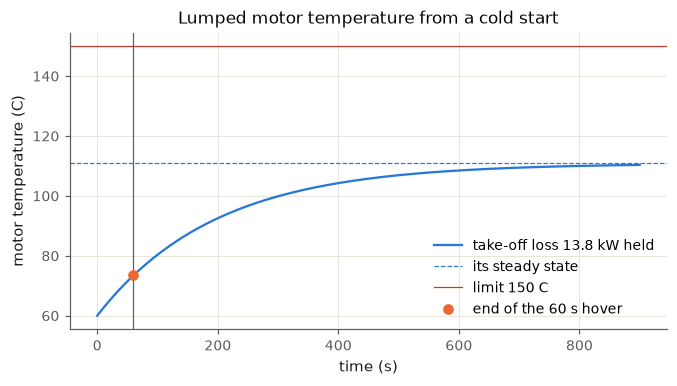

In [18]:
from aircraft_closure.powertrain.components.thermal import LumpedThermalModel
from aircraft_closure.thermal.heat import thermal_parameters, coolant_temperatures_C
thermal = motor.thermal_model
p = thermal_parameters(motor)
tau_s = thermal.time_constant_s(p.capacity_J_K, p.resistance_K_W)
take_off = rows["take-off hover"]
Q = take_off["heat_W"]["motor"] / instances["motor"].count           # per lane motor
print(f"motor: C {p.capacity_J_K/1e3:.1f} kJ/K, R {p.resistance_K_W*1e3:.3f} K/kW, tau {tau_s:.1f} s; "
      f"take-off loss {Q/1e3:.2f} kW per motor (continuous rating loss {p.power_loss_continuous_W/1e3:.2f} kW)")
T_end = thermal.temperature_end_C(Q, 60.0, p.capacity_J_K, p.resistance_K_W, 60.0)
print(f"end of take-off hover: {T_end:.3f} C (trace {take_off['temperatures_end_C']['motor']:.3f} C); "
      f"steady state would be {thermal.temperature_steady_C(Q, p.resistance_K_W):.1f} C")
check("take-off hover motor end temperature reproduced", abs(T_end - take_off["temperatures_end_C"]["motor"]) < 1e-9)
check("steady state at the continuous-rating loss is exactly the 150 C limit",
      abs(thermal.temperature_steady_C(p.power_loss_continuous_W, p.resistance_K_W) - 150.0) < 1e-9)
half = thermal.temperature_end_C(Q, 30.0, p.capacity_J_K, p.resistance_K_W, 60.0)
check("two 30 s steps chain exactly to one 60 s step",
      abs(thermal.temperature_end_C(Q, 30.0, p.capacity_J_K, p.resistance_K_W, half) - T_end) < 1e-9)
T_mean = thermal.temperature_mean_C(Q, 60.0, p.capacity_J_K, p.resistance_K_W, 60.0)
check("mean heat to coolant = loss - C (T_end - T_0)/dt",
      abs((T_mean - 60.0) / p.resistance_K_W - (Q - p.capacity_J_K * (T_end - 60.0) / 60.0)) < 1e-6)
check("zero numeric duration returns the start", thermal.temperature_end_C(Q, 0, 1.0, 1.0, 77.0) == 77.0)

t = np.linspace(0, 900, 300)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t, thermal.temperature_end_C(Q, t + 1e-12, p.capacity_J_K, p.resistance_K_W, 60.0), color=blue,
        label=f"take-off loss {Q/1e3:.1f} kW held")
ax.axhline(thermal.temperature_steady_C(Q, p.resistance_K_W), color=blue, ls="--", lw=0.8, label="its steady state")
ax.axhline(150, color=red, lw=0.8, label="limit 150 C")
ax.axvline(60, color=ink_muted, lw=0.8); ax.plot(60, T_end, "o", color=orange, label="end of the 60 s hover")
ax.set(xlabel="time (s)", ylabel="motor temperature (C)", title="Lumped motor temperature from a cold start")
ax.legend(); plt.show()

The take-off loss (13.8 kW per lane motor) is below the continuous loss (24.4 kW), so the motor would settle at
111 C; in 60 s with τ = 196 s it only reaches 73 C. The short-time rating is the point of the model: a loss above
the continuous one is allowed for as long as the end temperature stays under the limit. Its closed form is

$$Q_{max}(dt) = \frac{T_{max} - T_0}{R\,(1 - e^{-dt/\tau})} + \frac{T_0 - T_c}{R}$$

An `asb.Opti` finds the same number by maximizing Q subject to the end-temperature limit, exactly as the sizing
constrains the motor temperature margin:

In [19]:
opti = asb.Opti()
loss = opti.variable(init_guess=30e3, scale=1e4)
opti.subject_to(thermal.temperature_end_C(loss, 60.0, p.capacity_J_K, p.resistance_K_W, 60.0) <= 150.0)
opti.maximize(loss)
sol = opti.solve(verbose=False)
closed = (150.0 - 60.0) / (p.resistance_K_W * (1 - np.exp(-60.0 / tau_s)))
print(f"60 s rating from a cold start: {sol(loss)/1e3:.2f} kW (closed form {closed/1e3:.2f} kW) = "
      f"{sol(loss)/p.power_loss_continuous_W:.2f} x the continuous loss")
check("Opti short-time rating = closed form", abs(sol(loss) - closed) / closed < 1e-6)

60 s rating from a cold start: 92.64 kW (closed form 92.64 kW) = 3.79 x the continuous loss
PASS  Opti short-time rating = closed form


---
## 5. `powertrain/components/heat_exchanger.py`

In [20]:
show_source("src/aircraft_closure/powertrain/components/heat_exchanger.py", 1, 51)

# src/aircraft_closure/powertrain/components/heat_exchanger.py  lines 1-51
   1  """Ram-air liquid-to-air heat exchanger with ducts and hover fans (Tier 19, plan 028).
   2  
   3  Rating convention: `power_rated_W` is the heat rejected at the reference
   4  coolant-to-air temperature difference `delta_temperature_ref_C` (a
   5  difference, so kelvin and Celsius agree) with the rated air flow. Mass is
   6  rating / `specific_power_W_kg` and covers core, ducts, fans, pump and coolant.
   7  
   8  At an operating point with heat Q and ambient temperature T_a
   9  (dT = T_coolant - T_a, cp of air, air-side effectiveness eps):
  10  
  11  * air mass flow  m = Q / (eps cp dT);  rated flow m_ref = Q_rated / (eps cp dT_ref);
  12  * total-pressure loss dp = dp_ref (m / m_ref)^2 (rho_ref / rho), the
  13    turbulent quadratic law at the sea-level ISA reference density;
  14  * pumping power P = m dp / rho;
  15  * airplane mode (ram air): cooling drag D = P / V. Meredith (ARC R&M 1683):

**L1-27 docstring, the model.** Rating convention (L3-6): `power_rated_W` is the heat rejected at the **reference**
coolant-to-air difference dT_ref = 40 K with the rated air flow; mass = rating / 1 kW/kg covers core, ducts, fans,
pump and coolant (between Kellermann 2021, 0.62 kW/kg, and Potamiti 2024, 1.6 kW/kg; plan 028). At a point with heat
Q and dT = T_coolant - T_ambient:

$$\dot m = \frac{Q}{\varepsilon c_p\, dT}, \qquad \Delta p = \Delta p_{ref}\Big(\frac{\dot m}{\dot m_{ref}}\Big)^2\frac{\rho_{ref}}{\rho}, \qquad P_{pump} = \frac{\dot m\,\Delta p}{\rho}$$

- air flow from the air-side energy balance with effectiveness ε = 0.8: the air leaves at T_a + ε dT;
- pressure drop: the turbulent quadratic law, referenced to the rated flow at sea-level density. At fixed mass
  flow and lower density the velocity is higher, so Δp scales with 1/ρ;
- pumping power = volume flow x total-pressure loss.
- L15-17 airplane mode: cooling drag D = P_pump / V. Meredith (ARC R&M 1683): the drag power of a ducted radiator is
  the flow work lost in it. The heat-addition thrust recovery (the "Meredith effect") is not credited: conservative.
- L18-19 hover: no ram pressure, so fans supply P_pump at η_fan = 0.6: an electrical load on the bus, no drag.
- L20-21 required rating Q dT_ref / dT: the core conductance needed at this point's temperature difference; callers
  constrain it below the rating.
- L23-26: P_pump grows as Q^3/(dT^3 Q_rated^2), so a bigger (heavier) exchanger has less drag: a mass-drag trade
  the optimizer resolves through the rating design variable. dT must stay positive; nothing clips it.

**L33-34** module constants: c_p of air 1,005 J/(kg K) and the kelvin offset (the atmosphere returns K, the coolant is
in C). **L37-45 `HeatExchangerResult`**: all intermediate quantities are kept for reporting.
`power_heat_equivalent_W` here is computed from the heat **passed to `evaluate`**. **L48-50** limits: the rating.

In [21]:
show_source("src/aircraft_closure/powertrain/components/heat_exchanger.py", 53, 91)

# src/aircraft_closure/powertrain/components/heat_exchanger.py  lines 53-91
  53  @dataclass(frozen=True)
  54  class RamAirHeatExchanger:
  55      power_rated_W: Any = 300000.0
  56      specific_power_W_kg: Any = 1000.0      # at delta_temperature_ref_C; Kellermann 2021 ~0.6, Potamiti 2024 ~1.6 kW/kg
  57      temperature_coolant_C: Any = 60.0
  58      delta_temperature_ref_C: Any = 40.0
  59      effectiveness: Any = 0.8
  60      pressure_drop_ref_Pa: Any = 1000.0
  61      efficiency_fan: Any = 0.6
  62  
  63      def get_mass(self):
  64          return self.power_rated_W / self.specific_power_W_kg
  65  
  66      def get_limits(self):
  67          return HeatExchangerLimits(self.power_rated_W)
  68  
  69      def evaluate(self, power_heat_W, atmosphere, velocity_m_s=0.0, fan=False):
  70          delta_temperature_C = self.temperature_coolant_C - (atmosphere.temperature() - kelvin_offset_K)
  71          capacity_air_W_K = self.effectiveness * specific_heat_air_J_kg_K
  72

- **L55-61** defaults; the Halo overrides all of them from `HaloAssumptions` (`halo_sizing.py:354-359`) and
  `power_rated_W` from the design variable `power_rated_heat_exchanger_W`.
- **L63-64** mass linear in the rating. **L66-67** limits (unused by production code: `heat.py` reads
  `power_rated_W` directly).
- **L69-87 `evaluate`.**
  - L70 dT in C: coolant minus ambient (K to C via the offset).
  - L71-73 air capacity rate per unit mass flow, point flow, rated flow (rated flow is symbolic when the rating is).
  - L74-77 densities and the quadratic pressure drop. L75 builds a fresh sea-level `asb.Atmosphere` on every call:
    a constant, cheap, but recomputed each time.
  - L78 pumping power.
  - L79-82 the branch is on the Python flag `fan`, never on a symbol. The unused output is `0 * power_pumping_W`
    (keeps its type). With `fan=False` the drag divides by `velocity_m_s`, whose default is 0.0: calling `evaluate`
    in airplane mode without a velocity gives an infinite drag (Findings). The callers always pass V.
  - L86 the rating demand at this heat.
- **L90-91** smoke test.

**Run it on the sized exchanger.** Rating 126.9 kW (design variable), mass 126.9 kg. Reproduce the hot-day hover
(the point that sizes it, binding in `ref.binding`) and the first cruise point.

In [22]:
cooling = powertrain.cooling
exchanger = cooling.heat_exchanger
summary = ref.heat_exchanger
print(f"rating {exchanger.power_rated_W/1e3:.2f} kW, mass {exchanger.get_mass():.2f} kg; summary {summary['power_rated_W']/1e3:.2f} kW, "
      f"{summary['mass_kg']:.2f} kg")
check("exchanger mass = rating / 1 kW/kg and matches ref.heat_exchanger", abs(exchanger.get_mass() - summary["mass_kg"]) < 1e-9
      and abs(masses["heat_exchanger"] - summary["mass_kg"]) < 1e-9)
print("binding:", [b for b in ref.binding if "heat_exchanger" in b])

offset_K = temperature_offset_K(requirements.altitude_hover_hot_m, requirements.temperature_hover_hot_K)
hot_atmosphere = asb.Atmosphere(requirements.altitude_hover_hot_m, temperature_deviation=offset_K)
hot = rows["hot-day hover"]
r_hot = exchanger.evaluate(hot["power_heat_W"], hot_atmosphere, 0.0, fan=True)
print(f"\nhot-day hover: ambient {hot_atmosphere.temperature() - 273.15:.1f} C, dT {r_hot.delta_temperature_C:.2f} K, "
      f"mean heat {hot['power_heat_W']/1e3:.2f} kW -> air {r_hot.mass_flow_air_kg_s:.3f} kg/s, dp {r_hot.pressure_drop_Pa:.0f} Pa, "
      f"fan {r_hot.power_fan_W/1e3:.3f} kW (trace {hot['power_fan_W']/1e3:.3f} kW)")
check("hot-day fan power and air flow reproduced", abs(r_hot.power_fan_W - hot["power_fan_W"]) < 1e-6
      and abs(r_hot.mass_flow_air_kg_s - hot["mass_flow_air_kg_s"]) < 1e-12)
demand_end_W = hot["power_heat_end_W"] * 40.0 / r_hot.delta_temperature_C
print(f"rating demand from the END heat: {hot['power_heat_end_W']/1e3:.2f} kW x 40/25 = {demand_end_W/1e3:.2f} kW "
      f"= rating ({exchanger.power_rated_W/1e3:.2f} kW): binding")
print(f"HeatExchangerResult.power_heat_equivalent_W (from the MEAN heat) = {r_hot.power_heat_equivalent_W/1e3:.2f} kW")
check("the hot-day hover end heat sizes the exchanger exactly", abs(demand_end_W / exchanger.power_rated_W - 1) < 1e-6)

cruise = rows["cruise 1/4"]
cruise_atmosphere = asb.Atmosphere(3048.0)
r_cruise = exchanger.evaluate(cruise["power_heat_W"], cruise_atmosphere, ref.velocity_cruise_m_s)
print(f"\ncruise 1/4: dT {r_cruise.delta_temperature_C:.2f} K, heat {cruise['power_heat_W']/1e3:.1f} kW, "
      f"drag {r_cruise.drag_N:.3f} N (trace {cruise['drag_cooling_N']:.3f} N)")
check("cruise cooling drag reproduced", abs(r_cruise.drag_N - cruise["drag_cooling_N"]) < 1e-9)
check("pumping power scales as Q^3", abs(exchanger.evaluate(2 * 50e3, cruise_atmosphere, 80.0).power_pumping_W
                                         / exchanger.evaluate(50e3, cruise_atmosphere, 80.0).power_pumping_W - 8) < 1e-9)

rating 126.90 kW, mass 126.90 kg; summary 126.90 kW, 126.90 kg
PASS  exchanger mass = rating / 1 kW/kg and matches ref.heat_exchanger
binding: ['hot-day hover: heat_exchanger power_heat_W']



hot-day hover: ambient 35.0 C, dT 25.00 K, mean heat 68.88 kW -> air 3.427 kg/s, dp 934 Pa, fan 5.392 kW (trace 5.392 kW)
PASS  hot-day fan power and air flow reproduced
rating demand from the END heat: 79.32 kW x 40/25 = 126.90 kW = rating (126.90 kW): binding
HeatExchangerResult.power_heat_equivalent_W (from the MEAN heat) = 110.21 kW
PASS  the hot-day hover end heat sizes the exchanger exactly

cruise 1/4: dT 64.26 K, heat 71.0 kW, drag 2.938 N (trace 2.938 N)
PASS  cruise cooling drag reproduced
PASS  pumping power scales as Q^3


The hot day sizes the exchanger because dT is smallest there (25 K at 35 C ambient against 64 K in cruise at
10,000 ft): the required rating scales as 1/dT. The cruise drag is a few newtons: the 1/dT^3 law makes cold-air
cruise cheap.

The trade the rating resolves: a larger exchanger costs 1 kg per kW and cuts drag as 1/rating^2. As a toy problem,
price drag at 10 kg per newton and let an `asb.Opti` choose the rating for the cruise point alone; the closed form
from d/dR (R/s + k D_0 (R_0/R)^2) = 0 is R* = (2 k s D_0 R_0^2)^(1/3).

In [23]:
k_kg_N = 10.0
opti = asb.Opti()
rating = opti.variable(init_guess=100e3, scale=1e5, lower_bound=1e3)
toy = replace(exchanger, power_rated_W=rating)
opti.minimize(toy.get_mass() + k_kg_N * toy.evaluate(cruise["power_heat_W"], cruise_atmosphere,
                                                     ref.velocity_cruise_m_s).drag_N)
sol = opti.solve(verbose=False)
closed = (2 * k_kg_N * 1000.0 * r_cruise.drag_N * exchanger.power_rated_W**2) ** (1 / 3)
print(f"cruise-only optimum rating: {sol(rating)/1e3:.2f} kW (closed form {closed/1e3:.2f} kW) vs sized "
      f"{exchanger.power_rated_W/1e3:.2f} kW")
check("Opti rating = closed form of the mass-drag trade", abs(sol(rating) / closed - 1) < 1e-6)

cruise-only optimum rating: 98.18 kW (closed form 98.18 kW) vs sized 126.90 kW
PASS  Opti rating = closed form of the mass-drag trade


Even at 10 kg per newton of cruise drag (a high price) the cruise optimum, 98 kW, is below the 127 kW the hot-day
hover needs, so in the sizing the rating is set by the hot-day margin, not by the drag trade (it is in `ref.binding`).

---
## 6. `thermal/heat.py`: the discipline layer

In [24]:
show_source("src/aircraft_closure/thermal/heat.py", 1, 38)

# src/aircraft_closure/thermal/heat.py  lines 1-38
   1  """Heat loads, heat rejection and lumped component temperatures at one flight point (Tier 19, plan 028).
   2  
   3  Discipline layer: it reads losses that the component models already return
   4  and builds expressions only (no variables, no constraints; margins are
   5  returned for the caller to constrain).
   6  
   7  * `HeatLoad(source, power_W, count)`: the loss of one unit of an instance
   8    (`source` is the topology instance name, e.g. "motor", "generator_gearbox",
   9    and later Tier 15's "inverter" or "cable") and the number of units active.
  10    A new loss source plugs in by adding a `HeatLoad`; nothing here lists the
  11    sources.
  12  * `thermal_parameters(component)`: thermal capacitance C = c x component
  13    mass and resistance R = (T_max - T_coolant) / loss at the continuous
  14    rating, so the steady state at the continuous rating sits exactly on the
  15    temperature limit and the comp

**L1-31 docstring.** The layer reads losses the components already return and builds **expressions only** (L3-5): no
Opti variables, no constraints. It returns margins for the caller to constrain, like every other discipline (C01:
margins report, never clip).
- L7-11 `HeatLoad`: per-unit loss of a topology instance plus the active count. Sources are open: the module never
  lists them, a new source plugs in by adding a `HeatLoad` (this is how the Tier 18 contactors and the Tier 15 layer
  joined without edits here). L9 still says "later Tier 15's 'inverter' or 'cable'": the instance names are now
  `inverter_motor`, `cable_motor`, ... (stale wording, Findings).
- L12-20 `thermal_parameters`: C = c x mass; R = (T_max - T_c) / (loss at the continuous rating), so the steady
  state at the continuous rating is exactly the limit and "rated power" keeps its meaning as a continuous rating.
- L21-30 `evaluate_point_thermal`: temperatures and heat to the coolant for thermal-modelled instances, pass-through
  for the rest; the exchanger rejects every source not in `sources_excluded`; drag/fan follow the **mean** heat, the
  rating margin the **end** heat.

**L35-37 imports**: margins and the two battery classes (needed for `isinstance` dispatch in
`power_loss_continuous_W`).

In [25]:
show_source("src/aircraft_closure/thermal/heat.py", 40, 80)

# src/aircraft_closure/thermal/heat.py  lines 40-80
  40  @dataclass(frozen=True)
  41  class HeatLoad:
  42      source: str
  43      power_W: Any            # per unit
  44      count: Any = 1
  45  
  46      def total_W(self):
  47          return self.count * self.power_W
  48  
  49  
  50  def total_heat_W(heat_loads, sources_excluded=()):
  51      """Sum of count x power over every load whose source is not in `sources_excluded`."""
  52      return sum((load.total_W() for load in heat_loads if load.source not in sources_excluded), 0.0)
  53  
  54  
  55  @dataclass(frozen=True)
  56  class ThermalParameters:
  57      capacity_J_K: Any
  58      resistance_K_W: Any
  59      power_loss_continuous_W: Any
  60  
  61  
  62  def power_loss_continuous_W(component):
  63      """Loss at the component's continuous rating (see the module docstring)."""
  64      if isinstance(component, EquivalentCircuitBattery):
  65          current_A = component.get_limits().max_discharge_curre

- **L40-47 `HeatLoad(source, power_W, count)`**, `total_W` = count x power. `count` is `Any`: it is a Python int in
  practice (active units of a degraded state), but nothing forbids an expression.
- **L50-52 `total_heat_W`**: sum over loads not excluded. The `0.0` start value of `sum` keeps the result a float
  for an empty list and lets CasADi expressions add to it. Used by the tests only; `evaluate_point_thermal` does its
  own sums (it needs per-source mean and end heats).
- **L55-59 `ThermalParameters`**: C, R and the continuous-rating loss (reported in `heat_exchanger_summary`).
- **L62-71 `power_loss_continuous_W(component)`**, a type dispatch:
  - **L64-66 equivalent-circuit pack**: rated discharge current squared x the sum of the pack resistances
    (R0 + R1 + R2) at SOC 0.5, i.e. with the RC polarization fully developed (steady). `EquivalentCircuitBattery`
    and `Battery` are unrelated classes, so the order of the two `isinstance` tests does not matter;
  - **L67-68 constant battery**: (P_max / V_oc)^2 x R;
  - **L69-71 machines**: the McDonald loss at the rated speed and the torque that gives the rated power there. The
    rated speed is the loss model's peak-efficiency speed if it has one (`getattr` with a default), else the max
    speed. Voltage is passed for interface stability (McDonald losses do not depend on it).
- **L74-80 `thermal_parameters`**: C = c x `get_mass()` (so it follows the sized mass: symbolic in the sizing),
  R = (T_max - T_c) / loss. Both are expressions in the design variables, so a heavier motor has more thermal mass and
  a higher rating has a lower R.

**Run it**: reproduce the three entries of `ref.heat_exchanger["machines"]`.

In [26]:
from aircraft_closure.thermal.heat import (HeatLoad, evaluate_point_thermal, power_loss_continuous_W, total_heat_W)
for name in ("motor", "generator", "battery"):
    component = instances[name].component
    params = thermal_parameters(component)
    reported = summary["machines"][name]
    tau = params.capacity_J_K * params.resistance_K_W
    print(f"{name:<9} mass {component.get_mass():7.2f} kg  C {params.capacity_J_K/1e3:7.1f} kJ/K  "
          f"R {params.resistance_K_W*1e3:6.3f} K/kW  continuous loss {params.power_loss_continuous_W/1e3:7.2f} kW  "
          f"tau {tau:6.1f} s  coolant {component.thermal_model.temperature_coolant_C:.0f} C  "
          f"limit {component.thermal_model.temperature_max_C:.0f} C")
    check(f"{name}: continuous loss and time constant reproduce ref.heat_exchanger",
          abs(params.power_loss_continuous_W - reported["power_loss_continuous_W"]) < 1e-6
          and abs(tau - reported["time_constant_s"]) < 1e-9)
print("coolant_temperatures_C:", coolant_temperatures_C(powertrain))

motor     mass  106.39 kg  C    53.2 kJ/K  R  3.682 K/kW  continuous loss   24.44 kW  tau  195.9 s  coolant 60 C  limit 150 C
PASS  motor: continuous loss and time constant reproduce ref.heat_exchanger
generator mass  140.85 kg  C    70.4 kJ/K  R  1.926 K/kW  continuous loss   46.74 kW  tau  135.6 s  coolant 60 C  limit 150 C
PASS  generator: continuous loss and time constant reproduce ref.heat_exchanger
battery   mass  475.12 kg  C   475.1 kJ/K  R  0.239 K/kW  continuous loss  146.27 kW  tau  113.7 s  coolant 25 C  limit 60 C
PASS  battery: continuous loss and time constant reproduce ref.heat_exchanger
coolant_temperatures_C: {'generator': 60.0, 'battery': 25.0, 'motor': 60.0}


The pack's continuous loss is 146 kW at its rated discharge current (1,125 A pack, SOC 0.5 with polarization): the
pack is rated far above its normal use, so its R is small and its 475 kg x 1,000 J/(kg K) thermal mass does the work
in the engine-out hover.

In [27]:
show_source("src/aircraft_closure/thermal/heat.py", 83, 143)

# src/aircraft_closure/thermal/heat.py  lines 83-143
  83  @dataclass(frozen=True)
  84  class PointThermal:
  85      heat_loads: tuple
  86      power_heat_W: Any                   # interval-mean heat into the heat exchanger (0 without one)
  87      power_heat_end_W: Any               # at the end of the interval
  88      power_heat_equivalent_W: Any        # end heat at the exchanger's reference temperature difference (rating demand)
  89      cooling: Any                        # HeatExchangerResult at the mean heat, or None
  90      temperatures_end_C: dict            # instance name -> temperature at the end of the interval
  91      temperatures_mean_C: dict           # instance name -> interval-mean temperature
  92      power_to_coolant_W: dict            # instance name -> interval-mean heat to the coolant, per unit
  93      margins: tuple
  94  
  95  
  96  def evaluate_point_thermal(powertrain, heat_loads, atmosphere, velocity_m_s, mode, duration_s=0.0,
  97          

**L83-93 `PointThermal`**: the loads, three exchanger heats (mean, end, end at the reference difference), the
`HeatExchangerResult`, per-instance end and mean temperatures, per-unit mean heat to coolant, margins.
`temperatures_mean_C` is filled but read nowhere in the repository.

**L96-136 `evaluate_point_thermal`.**
- **L96-101** signature: the powertrain (topology + cooling), the loads, the atmosphere, the speed, the mode, the
  interval duration, start temperatures (None or a dict by instance name), a label for the margins, and
  `components` (Tier 18): a per-point substitute component. The string-out hover passes the pack with one string
  isolated, which has half the mass (C) and its own R.
- **L105-111** for each load, look up the component (L106: a source that is not an instance gets None); L107 apply
  the override; L108 no `thermal_model` means pass-through: mean and end heat to the exchanger = the loss itself
  (gearboxes, contactors, tie cable, and Tier 15 inverters/cables if the layer were on).
- **L112-118** thermal instances: C and R, the start (None or the dict entry), end and mean temperatures, then mean
  and end heat to the coolant per unit, (T - T_c)/R.
- **L119-120 temperature margin** = (T_max - T_end)/(T_max - T_c): normalized by the allowed rise, so 1 at the
  coolant temperature, 0 at the limit. Only the **end** is constrained, which suffices by the monotonicity of
  section 4.
- **L121-132 the exchanger.** L126 the rejected loads (all but `sources_excluded`; the Halo excludes `gearbox` and
  `generator_gearbox`, whose oil coolers are inside the AFDD drive weights). L127-128 sum count x per-unit heat, mean
  and end. L129 the exchanger is evaluated at the **mean** heat (drag and fan power are energy over the interval) with
  `fan=(mode == "hover")`. L130 the rating demand uses the **end** heat (the peak within the interval, since heat to
  coolant moves monotonically with T) at this point's dT. L131-132 the rating margin.
- **L133-136** return. `power_to_coolant_W` is the per-unit **mean** dict.

**L139-143 `coolant_temperatures_C`**: the cold-start dict, every thermal instance at its own coolant temperature
(60 C machines, 25 C pack).

**Run it: reproduce `ref.thermal_trace` rows from the rebuilt aircraft.** A trace row stores the total heat per
source (count x per unit). The cell divides by the active count of that point (lanes lost in the bus-out hover,
one engine in the engine-out hover, one string in the string-out hover), rebuilds the `HeatLoad`s, and calls
`evaluate_point_thermal` with the point's atmosphere, speed, duration and start temperatures, following the chaining
of `solve_halo_sizing` (section 7).

In [28]:
from aircraft_closure.powertrain.redundancy import battery_with_strings
trace = ref.thermal_trace
def active_counts(label):
    counts = {name: instance.count for name, instance in instances.items()}
    if label.startswith("bus-out"):
        counts["motor"] = counts["motor"] // 2                    # one lane per rotor lost
    if label.startswith("engine-out"):
        counts["generator"] = counts["generator_gearbox"] = 1
    if label.startswith("string-out"):
        counts["protection_string"] = 1
    return counts

def rebuild(label, start_C, altitude_m, velocity_m_s, offset_K=0.0, duration_s=None):
    row = rows[label]
    counts = active_counts(label)
    loads = [HeatLoad(source, total / counts[source], counts[source]) for source, total in row["heat_W"].items()]
    override = ({"battery": battery_with_strings(battery, 0.5)} if label.startswith("string-out") else None)
    point = evaluate_point_thermal(powertrain, loads, asb.Atmosphere(altitude_m, temperature_deviation=offset_K),
                                   velocity_m_s, row["mode"], duration_s if duration_s is not None
                                   else (row["duration_s"] or 0.0), start_C, label, components=override)
    pairs = [(point.power_heat_W, row["power_heat_W"]), (point.power_heat_end_W, row["power_heat_end_W"]),
             (point.power_heat_equivalent_W, row["power_heat_equivalent_W"]),
             (point.cooling.drag_N, row["drag_cooling_N"]), (point.cooling.power_fan_W, row["power_fan_W"]),
             *[(point.temperatures_end_C[k], v) for k, v in row["temperatures_end_C"].items()]]
    error = max(abs(float(a) - b) / max(abs(b), 1.0) for a, b in pairs)
    return point, error

cases = [  # label, start temperatures, altitude, speed, offset, duration
    ("take-off hover", coolant_temperatures_C(powertrain), 0.0, 0.0, 0.0, None),
    ("climb", rows["take-off hover"]["temperatures_end_C"], 3048.0 / 2, 80.0, 0.0, None),
    ("cruise 1/4", rows["climb"]["temperatures_end_C"], 3048.0, ref.velocity_cruise_m_s, 0.0, None),
    ("engine-out hover 1/3", rows["take-off hover"]["temperatures_end_C"], 0.0, 0.0, 0.0, None),
    ("engine-out hover 3/3", rows["engine-out hover 2/3"]["temperatures_end_C"], 0.0, 0.0, 0.0, None),
    ("bus-out hover 3/3", rows["bus-out hover 2/3"]["temperatures_end_C"], 0.0, 0.0, 0.0, None),
    ("string-out hover 3/3", rows["string-out hover 2/3"]["temperatures_end_C"], 0.0, 0.0, 0.0, None),
    ("hover", coolant_temperatures_C(powertrain), requirements.altitude_hover_m, 0.0, 0.0, requirements.duration_hover_s),
    ("max_speed", None, requirements.altitude_cruise_m, requirements.velocity_max_m_s, 0.0, None),
    ("hot-day hover", rows["landing hover"]["temperatures_end_C"], requirements.altitude_hover_hot_m, 0.0, offset_K,
     requirements.duration_hover_hot_s),
]
print(f"{'row':<22}{'Q mean kW':>10}{'Q end kW':>10}{'demand kW':>10}{'drag N':>8}{'fan kW':>8}"
      f"{'T motor':>9}{'T gen':>7}{'T batt':>8}{'rel err':>10}")
points = {}
for label, start, altitude, speed, offset, duration in cases:
    point, error = rebuild(label, start, altitude, speed, offset, duration)
    points[label] = point
    T = point.temperatures_end_C
    print(f"{label:<22}{point.power_heat_W/1e3:10.2f}{point.power_heat_end_W/1e3:10.2f}"
          f"{point.power_heat_equivalent_W/1e3:10.2f}{float(point.cooling.drag_N):8.2f}"
          f"{float(point.cooling.power_fan_W)/1e3:8.3f}{T['motor']:9.2f}{T['generator']:7.2f}{T['battery']:8.2f}{error:10.1e}")
    check(f"thermal_trace row '{label}' reproduced (rel. error < 1e-9)", error < 1e-9)

row                    Q mean kW  Q end kW demand kW  drag N  fan kW  T motor  T gen  T batt   rel err
take-off hover             19.04     35.76     31.79    0.00   0.013    73.42  79.86   25.13   2.8e-16
PASS  thermal_trace row 'take-off hover' reproduced (rel. error < 1e-9)
climb                      86.37    106.19     77.84    6.75   0.000   114.34 103.95   25.36   3.9e-16
PASS  thermal_trace row 'climb' reproduced (rel. error < 1e-9)
cruise 1/4                 70.97     67.86     42.24    2.94   0.000    90.63  93.29   25.00   1.0e-15
PASS  thermal_trace row 'cruise 1/4' reproduced (rel. error < 1e-9)
engine-out hover 1/3       40.53     54.62     48.55    0.00   0.123    77.06  87.10   30.22   3.8e-15
PASS  thermal_trace row 'engine-out hover 1/3' reproduced (rel. error < 1e-9)
engine-out hover 3/3       96.79    111.22     98.86    0.00   1.673    83.30  98.75   40.68   2.4e-15
PASS  thermal_trace row 'engine-out hover 3/3' reproduced (rel. error < 1e-9)
bus-out hover 3/3      

Every row reproduces to round-off, which confirms the chaining read from the code: the mission starts cold, each
sub-segment starts where the previous one ended, the engine-out and failure hovers start from the end of the
take-off hover, the 4,000 ft hover requirement starts cold, the hot-day hover continues from the end of the mission
(landing hover), and the airplane-mode requirement points (`max_speed`) are steady (start None).

**What the thermal mass does.** In the take-off hover the rejected losses total far more than what reaches the
exchanger: the components absorb the rest.

In [29]:
t_o = points["take-off hover"]
rejected_loss_W = total_heat_W(t_o.heat_loads, cooling.sources_excluded)
print(f"take-off hover: rejected-source losses {rejected_loss_W/1e3:.1f} kW, mean heat to the exchanger "
      f"{t_o.power_heat_W/1e3:.1f} kW, end {t_o.power_heat_end_W/1e3:.1f} kW; gearbox heat to oil coolers "
      f"{(total_heat_W(t_o.heat_loads) - rejected_loss_W)/1e3:.1f} kW")
for load in t_o.heat_loads:
    print(f"  {load.source:<18} loss {load.total_W()/1e3:8.3f} kW -> to coolant {load.count * t_o.power_to_coolant_W[load.source]/1e3:8.3f} kW")
check("thermal mass absorbs most of the cold-start hover heat", t_o.power_heat_W < 0.2 * rejected_loss_W)
steady = points["max_speed"]
check("steady point (start None): heat to coolant = loss", abs(steady.power_heat_W
                                                               - total_heat_W(steady.heat_loads, cooling.sources_excluded)) < 1e-6)
margins = {m.label: m.value for m in points["hot-day hover"].margins}
print({k: round(float(v), 4) for k, v in margins.items()})
check("hot-day hover: exchanger margin ~ 0 (binding)", abs(margins["hot-day hover: heat_exchanger power_heat_W"]) < 1e-6)

take-off hover: rejected-source losses 114.3 kW, mean heat to the exchanger 19.0 kW, end 35.8 kW; gearbox heat to oil coolers 54.0 kW
  motor              loss   55.265 kW -> to coolant    7.662 kW
  gearbox            loss   26.562 kW -> to coolant   26.562 kW
  generator          loss   57.692 kW -> to coolant   11.072 kW
  battery            loss    1.341 kW -> to coolant    0.299 kW
  generator_gearbox  loss   27.401 kW -> to coolant   27.401 kW
  protection_string  loss    0.003 kW -> to coolant    0.003 kW
PASS  thermal mass absorbs most of the cold-start hover heat
PASS  steady point (start None): heat to coolant = loss
{'hot-day hover: motor temperature_C': 0.6658, 'hot-day hover: generator temperature_C': 0.6129, 'hot-day hover: battery temperature_C': 0.9288, 'hot-day hover: heat_exchanger power_heat_W': -0.0}
PASS  hot-day hover: exchanger margin ~ 0 (binding)


---
## 7. How the Halo uses them

### 7.1 Thermal models on the machines and the pack

In [30]:
show_source("examples/halo_sizing.py", 347, 368)
show_source("examples/halo_sizing.py", 458, 464)
show_source("examples/halo_sizing.py", 672, 677)

# examples/halo_sizing.py  lines 347-368
 347      # ---- Tier 19 thermal (plan 028) ----
 348      # True: heat loads from every loss go to a ram-air heat exchanger (mass from its rating, a design variable;
 349      # cooling drag in airplane mode, fan power in hover), and lumped motor and generator temperatures replace
 350      # their power ratings (hover and engine-out peaks may exceed the continuous rating for their duration). The
 351      # rotor gearbox is then rated separately (`HaloDesign.power_rated_gearbox_W`). True is the reference from plan 030
 352      # (adopted 2026-10-04); False: the reference until then (`assumptions_plan027`).
 353      thermal_model: bool = True
 354      specific_power_heat_exchanger_W_kg: float = 1000.0   # at the 40 K reference (Kellermann 2021, Potamiti 2024)
 355      delta_temperature_ref_heat_exchanger_C: float = 40.0
 356      temperature_coolant_C: float = 60.0                  # water-glycol loop into the heat exchanger and machines
 3

- **L347-368** the thermal assumptions (plan 028, default from plan 030). L362-363: the pack's loop is held at the
  25 C managed cell temperature; moving that heat into the 60 C loop needs a chiller that is not modelled. L366-368:
  `sources_excluded_heat_exchanger = ("gearbox", "generator_gearbox")`.
- **L458-464 `battery_thermal`**: returns `{}` with thermal off, else a dict that is splatted (`**`) into the battery
  constructor, so the battery classes need no thermal-specific branch. Note the argument order of
  `LumpedThermalModel(c, T_max, T_coolant)`: the pack's "coolant" is the cell temperature, 25 C.
- **L672-677** the same pattern for the machines: one shared `LumpedThermalModel` instance for motor and generator
  (frozen, so sharing is safe).

### 7.2 The electrical layer (off in the baseline)

In [31]:
show_source("examples/halo_sizing.py", 247, 268)
show_source("examples/halo_sizing.py", 486, 509)

# examples/halo_sizing.py  lines 247-268
 247      # ---- Tier 15 electrical layer (plan 023) ----
 248      # True inserts inverters (motors) and active rectifiers (generators), DC feeder cables and protection
 249      # between the machines, the battery and the bus, and sizes the machines as bare machines. False keeps the
 250      # machines connected to the bus directly, with the integrated Tier 13 machine figures above.
 251      electrical_layer: bool = False
 252      # Bare-machine figures that keep the Tier 13 integrated calibration: 1/15 = 1/17.6 + 200 rad/s / 20 kW/kg
 253      # (magniX at its speed) and 1/10 kW/kg = 1/20 + 1/20 (high-speed cap). 20 kW/kg is above NASA's HEMM
 254      # 16 kW/kg electromagnetic target, i.e. the Tier 13 cap was optimistic (plan 023 sensitivity).
 255      torque_density_machine_bare_Nm_kg: float = 17.6
 256      specific_power_max_machine_bare_W_kg: float = 20000.0
 257      specific_power_inverter_W_kg: float = 20000.0      # NASA EAP goa

- **L247-268** the Tier 15 assumptions. L251 `electrical_layer = False`. L252-256 the bare-machine figures that keep
  the Tier 13 integrated calibration when the inverter becomes separate: 1/15 = 1/17.6 + 200/20,000. L261 machines
  and inverters work down to 0.9 x the pack minimum. L262 feeder length = 1.25 x half span. L264 the 125 % feeder
  rule.
- **L486-504 `BusVoltageWindow` / `bus_voltage_window`**: with no DC/DC the pack sets the bus: 210 x (3.6, 2.5, 4.2) V
  = 756 / 525 / 882 V; with a DC/DC all three equal the regulated voltage. The fourth field is the derated
  semiconductor limit, 900 V.
- **L507-509 `power_electric_rated_W`** = shaft rating / McDonald peak efficiency: the electrical input of a motor at
  its rating. It rates the inverters, the feeders and the bus tie.

In [32]:
show_source("examples/halo_sizing.py", 512, 565)

# examples/halo_sizing.py  lines 512-565
 512  def build_halo_electrical(motor, generator, battery, span_m, requirements=HaloRequirements(),
 513                            assumptions=HaloAssumptions()):
 514      """Tier 15 feeders: inverters at machine rating, cables and protection sized at rated power and the
 515      lowest bus voltage (battery: its discharge current rating), insulation for the highest bus voltage at the
 516      ceiling."""
 517      a, window = assumptions, bus_voltage_window(assumptions)
 518      cell = inr21700_50g_cell()
 519      pack_min_V = a.count_series_battery * cell.voltage_min_V
 520      pack_max_V = a.count_series_battery * cell.voltage_max_V
 521      if isinstance(battery, EquivalentCircuitBattery):
 522          current_battery_max_A = battery.get_limits().max_discharge_current_A
 523          power_battery_max_W = battery.power_max_discharge_W
 524      else:
 525          current_battery_max_A = battery.max_discharge_power_W / pack_min_V
 52

**L512-565 `build_halo_electrical`.**
- L519-526 the pack's current and power ratings, by battery type (the ECM has a current rating; the constant battery
  a power rating, turned into a current at the minimum pack voltage).
- L527 one loss model, rated at the nominal bus voltage, shared by both inverters (that is why the rating is an
  argument of `ConverterLossModel.evaluate`).
- L530-535 `inverter(machine)`; L537-543 `feeder(length, current, V_max)` returns a (Cable, ProtectionUnit) pair at
  125 % of the source current. The comment L538-539 records the reason from plan 023: feeders at exactly the source
  rating duplicated the battery's own current limit; with three identical active constraints IPOPT reported local
  infeasibility.
- L545-553 motor and generator feeders at rated electrical power over the **minimum** bus voltage (the worst current),
  insulated for the **maximum** bus voltage; the battery feeder at the pack's discharge current, insulated for the
  pack maximum. L549: since plan 037 the turbogenerators are in the fuselage, so their feeder is the short 3 m one.
- L554-561 optional DC/DC, rated at the pack's discharge power.

### 7.3 The redundancy hardware (on in the baseline)

In [33]:
show_source("examples/halo_sizing.py", 568, 603)

# examples/halo_sizing.py  lines 568-603
 568  def count_lanes_motor(assumptions):
 569      """Tier 18: lane motors per rotor (1 without the redundancy option)."""
 570      return assumptions.count_lanes_motor if assumptions.redundancy else 1
 571  
 572  
 573  def build_halo_redundancy(generator, battery, requirements=HaloRequirements(), assumptions=HaloAssumptions()):
 574      """Tier 18 architecture: string contactors at 125 % of a string's discharge current rating; each bus tie
 575      (contactor + cable) at 125 % of the rated current of one bus's sources (its share of the generators'
 576      electrical rating and of the pack's discharge rating) at the lowest bus voltage. None without the option."""
 577      a = assumptions
 578      if not a.redundancy:
 579          return None
 580      window = bus_voltage_window(a)
 581      cell = inr21700_50g_cell()
 582      pack_max_V = a.count_series_battery * cell.voltage_max_V
 583      if isinstance(battery, EquivalentCircuitB

- **L568-570** lanes per rotor (1 without redundancy).
- **L583-588** the pack ratings again (same dispatch as `build_halo_electrical`; duplicated code).
- **L589-592 string contactors**: one `ProtectionUnit` per string at 1.25 x (pack discharge current / strings),
  insulated for the pack maximum. Only built with more than one string.
- **L593-600 bus ties**: the tie current rating is 125 % of one bus's share of all sources at the minimum bus voltage:

$$I_{tie} = 1.25\,\frac{n_{gen}\,P_{gen,el} + P_{batt,max}}{B\,V_{min}}$$

  The contactor and the 2 m cable share this rating; the cable's insulation is designed for the max bus voltage at
  the ceiling, like a feeder.

Rebuild both from the sized machines and check them against the topology instances:

In [34]:
redundancy = build_halo_redundancy(generator, battery, requirements, assumptions)
current_battery_max_A = battery.get_limits().max_discharge_current_A
by_hand_string_A = 1.25 * current_battery_max_A / assumptions.count_strings_battery
by_hand_tie_A = 1.25 * (assumptions.count_turbogenerators * power_electric_rated_W(generator)
                        + battery.power_max_discharge_W) / (assumptions.count_buses * window.voltage_min_V)
print(f"pack discharge rating {current_battery_max_A:.1f} A -> string contactor {by_hand_string_A:.1f} A")
print(f"generators {assumptions.count_turbogenerators} x {power_electric_rated_W(generator)/1e3:.1f} kW electrical + "
      f"pack {battery.power_max_discharge_W/1e3:.1f} kW, over {assumptions.count_buses} buses at {window.voltage_min_V:.0f} V "
      f"-> tie {by_hand_tie_A:.1f} A")
check("string contactor rating by hand = rebuilt = topology instance",
      abs(redundancy.protection_string.max_current_A - by_hand_string_A) < 1e-9 and redundancy.protection_string == string)
check("bus tie rating by hand = rebuilt = topology instances",
      abs(redundancy.protection_bus_tie.max_current_A - by_hand_tie_A) < 1e-9
      and redundancy.protection_bus_tie == tie and redundancy.cable_bus_tie == tie_cable)
check("no electrical-layer instances in the baseline topology", "inverter_motor" not in instances)

pack discharge rating 1124.7 A -> string contactor 702.9 A
generators 2 x 984.4 kW electrical + pack 850.3 kW, over 2 buses at 525 V -> tie 3356.0 A
PASS  string contactor rating by hand = rebuilt = topology instance
PASS  bus tie rating by hand = rebuilt = topology instances
PASS  no electrical-layer instances in the baseline topology


### 7.4 Installation: locations, the cooler and its mass

In [35]:
show_source("examples/halo_sizing.py", 759, 764)
show_source("examples/halo_sizing.py", 844, 876)
show_source("src/aircraft_closure/vehicle/powertrain_installation.py", 32, 37)
show_source("src/aircraft_closure/vehicle/powertrain_installation.py", 57, 67)

# examples/halo_sizing.py  lines 759-764
 759      electrical = (build_halo_electrical(motor, generator, battery, np.sqrt(d.area_wing_m2 * a.aspect_ratio_wing),
 760                                          requirements, a) if a.electrical_layer else None)
 761      redundancy = build_halo_redundancy(generator, battery, requirements, a)
 762      topology = build_series_hybrid(motor, generator, battery, turboshaft, gearbox, rotor, count_rotors=a.count_rotors,
 763                                     count_turbogenerators=a.count_turbogenerators, generator_gearbox=generator_gearbox,
 764                                     electrical=electrical, redundancy=redundancy)
# examples/halo_sizing.py  lines 844-876
 844      if electrical is not None:
 845          # Inverters in the tip nacelles with their machines; nacelle feeders along the wing quarter chord;
 846          # protection at the bus next to the battery.
 847          x_bus_m, z_bus_m = x_rotor_m - 0.8, -0.2
 848          locat

- **halo_sizing L759-764**: the electrical layer is built only with the switch; the redundancy layer (None without its
  switch) is always passed to `build_series_hybrid`, which adds `protection_string` (count = strings),
  `protection_bus_tie` and `cable_bus_tie` (count = buses - 1) as instances.
- **L844-858** the layer's locations (skipped in the baseline). **L859-866** string contactors and the tie at the bus
  next to the battery (x_rotor - 0.8 m, z -0.2 m). Every instance must be located exactly once
  (`PowertrainInstallation.__post_init__`).
- **L867-876** one `InstalledCooling` with the `RamAirHeatExchanger` built from the assumptions and the design
  variable `power_rated_heat_exchanger_W`, at the wing (x_rotor), with `sources_excluded`.
- **powertrain_installation L32-37 `InstalledCooling`**: the exchanger, its position, the excluded sources. It is not
  a topology instance (no power ports); its fan power is a bus load added by the flight point.
- **L57-67**: instance masses are count x `get_mass()` (so 2 string contactors, 1 tie pair); the exchanger adds the
  item "heat_exchanger" with its own CG. That is the 126.9 kg in `ref.powertrain_masses_kg`.

### 7.5 The flight point: string and tie currents, heat loads, the call to `evaluate_point_thermal`

In [36]:
show_source("src/aircraft_closure/performance/flight_point.py", 171, 179)
show_source("src/aircraft_closure/performance/flight_point.py", 206, 209)
show_source("src/aircraft_closure/performance/flight_point.py", 251, 262)
show_source("src/aircraft_closure/performance/flight_point.py", 273, 283)

# src/aircraft_closure/performance/flight_point.py  lines 171-179
 171      has_strings = "protection_string" in instances
 172      has_redundancy = has_strings or state.counts.count_lanes > 1 or state.counts.count_buses > 1
 173      battery_model = battery_with_strings(battery_model, state.fraction_strings_active)
 174      components_override = {"battery": battery_model} if state.fraction_strings_active != 1 else {}
 175      weight_N = mass_kg * acceleration_gravity_m_s2
 176      temperature_offset_K = condition.temperature_offset_K
 177      atmosphere = asb.Atmosphere(altitude=condition.altitude_m, temperature_deviation=temperature_offset_K)
 178      has_cooling = getattr(aircraft.powertrain, "cooling", None) is not None
 179      drag_cooling_N = 0.0
# src/aircraft_closure/performance/flight_point.py  lines 206-209
 206          if has_cooling:
 207              # Tier 19: cooling drag as a variable, tied to the heat exchanger's drag below.
 208              drag_cooling_N = 

- **L171-176**: `has_strings` from the instance names; the string-out state replaces the pack by
  `battery_with_strings(...)` and records it in `components_override`, which is passed to `evaluate_point_thermal`
  (L376) so the isolated-string pack uses its own C and R. **L178** `has_cooling`.
- **L206-209** airplane mode with cooling: the cooling drag is an Opti **variable** (lower bound 0) added to the
  thrust requirement. It is tied to the exchanger drag later (L383). Drag depends on heat, heat on the losses, losses
  on thrust: one variable and one equality replace a fixed-point loop.
- **L251-262** string contactors: the pack current splits over the active strings (L253); their resistance in
  parallel, R/S_active, is in series with the pack (L255), and the bus voltage is the exact series drop
  V_bus = V_terminal - I R (L260).
- **L273-283** the bus tie: only in a bus-out state (L276). The tie carries the failed bus's share of the motor
  demand at the bus voltage (first order, L277-278): I_tie = n_failed x P_motors / (B x V_bus). Contactor and cable
  evaluated at that current; their loss is added to the bus demand (L378-379). The tie port values are built in
  all states for the margins.

In [37]:
show_source("src/aircraft_closure/performance/flight_point.py", 353, 383)

# src/aircraft_closure/performance/flight_point.py  lines 353-383
 353      # Tier 19: heat loads by source (per unit, active count); new loss sources add a HeatLoad here.
 354      heat_loads = (HeatLoad("motor", motor.power_loss_W, count_motors_active),
 355                    HeatLoad("gearbox", gear.power_loss_W, active_rotor_count),
 356                    HeatLoad("generator", generator.power_loss_W, active_generator_count),
 357                    HeatLoad("battery", battery.power_loss_W, 1))
 358      if generator_gear_ports:
 359          heat_loads += (HeatLoad("generator_gearbox", generator_gear.power_loss_W, active_generator_count),)
 360      if electrical is not None:
 361          heat_loads += electrical.heat_loads          # Tier 15: inverters, cables, protection, DC/DC by instance
 362      redundancy = None
 363      if has_redundancy:
 364          power_loss_strings_W = state.count_strings_active * protection_string.power_loss_W if has_strings else 0.0
 365        

- **L353-361** the base heat loads, **per unit with the active count**: motors (active rotors x active lanes),
  rotor gearboxes, generators, the pack, the generator step-up gearboxes, and the Tier 15 loads (named after their
  instances) when the layer is on.
- **L363-369** Tier 18: string contactor heat with the active string count; the tie contactor and cable heats only in a
  bus-out state.
- **L375-376 the call**: powertrain, loads, the point's atmosphere and speed, `condition.mode`, the interval
  `duration_s` and `temperature_start_C` (passed in by the mission or the sizing), the label, the override.
- **L377-381** the bus demand adds the tie loss and the exchanger **fan power** (zero in airplane mode).
- **L382-383** the cooling-drag equality, normalized by 1 % of the weight so IPOPT sees an O(1) residual.
- The thermal margins (temperature and rating) are appended to the operating margins at L445; with the ties
  normally open and no bus failed, the tie margins are removed (L441-444).

### 7.6 Where the start temperatures come from, and what the result records

In [38]:
show_source("src/aircraft_closure/mission/mission.py", 82, 89)
show_source("src/aircraft_closure/mission/mission.py", 111, 112)
show_source("examples/halo_sizing.py", 1199, 1210)
show_source("examples/halo_sizing.py", 1235, 1249)

# src/aircraft_closure/mission/mission.py  lines 82-89


  82      if isinstance(thermal_start, dict):
  83          temperatures_C = dict(thermal_start)
  84      elif thermal_start == "coolant":
  85          temperatures_C = coolant_temperatures_C(aircraft.powertrain)
  86      elif thermal_start == "steady":
  87          temperatures_C = None
  88      else:
  89          raise ValueError(f"Unknown thermal_start '{thermal_start}'.")
# src/aircraft_closure/mission/mission.py  lines 111-112
 111              if temperatures_C is not None:
 112                  temperatures_C = point.thermal.temperatures_end_C
# examples/halo_sizing.py  lines 1199-1210
1199                            **(dict(subsegments=a.subsegments_mission) if is_ecm else {}),
1200                            # Tier 19: machines start at the coolant temperature and carry their history.
1201                            **(dict(thermal_start="coolant") if thermal else {}))
1202      # Tier 19: the hover requirement is a 60 s hover from a cold start; airplane-mode requiremen

- **mission L82-89** `thermal_start`: a dict, "coolant" (`coolant_temperatures_C`) or "steady" (None). **L111-112**
  each point's end temperatures become the next point's start: the thermal history is a chain of closed-form steps.
- **halo_sizing L1199-1201** the mission starts cold. **L1202-1207** the requirement points: hovers are 60 s from a
  cold start, airplane-mode points steady. **L1208-1210** the end of the take-off hover's last sub-segment is the
  engine-failure start.
- **L1235-1244** the hot-day hover continues from the mission's end temperatures (after the landing hover).
- **L1247-1249** the failure hovers start from `take_off_end_C` too (`halo_failure_hovers`).

These are exactly the starts used by the reproduction in section 6.

In [39]:
show_source("examples/halo_sizing.py", 1524, 1561)

# examples/halo_sizing.py  lines 1524-1561
1524  def thermal_trace(segment_points, other_points, value):
1525      """Numeric thermal state per point (Tier 19): segment results (with durations) then single flight points."""
1526      rows = []
1527      for duration_s, p in ([(s.duration_s, s.point) for s in segment_points] + [(None, p) for p in other_points]):
1528          t = p.thermal
1529          rows.append(dict(
1530              label=p.condition.label, mode=p.condition.mode,
1531              duration_s=value(duration_s) if duration_s is not None else None,
1532              heat_W={load.source: value(load.total_W()) for load in t.heat_loads},
1533              power_heat_W=value(t.power_heat_W), drag_cooling_N=value(t.cooling.drag_N),
1534              power_fan_W=value(t.cooling.power_fan_W), power_heat_equivalent_W=value(t.power_heat_equivalent_W),
1535              mass_flow_air_kg_s=value(t.cooling.mass_flow_air_kg_s),
1536              delta_temperature_C=value(t.coolin

- **L1524-1541 `thermal_trace`**: one row per mission sub-segment (with its duration), then the engine-out
  sub-segments and failure sub-segments (`solve_halo_sizing` passes them in that order), then the single points
  (requirements, the hot-day hover). `heat_W` is **total** per source (`load.total_W()`), `power_to_coolant_W` is
  **per unit** (the dict from L136 of heat.py): mixing the two is easy, the reproduction above divides by the count.
  `power_heat_equivalent_W` is the PointThermal (end-heat) value, not `cooling.power_heat_equivalent_W`.
- **L1544-1561 `heat_exchanger_summary`**: rating, mass, the rotor gearbox rating (a separate design variable with
  thermal on), and per motor/generator/battery: rating, mass, continuous loss, time constant.

In [40]:
print(f"{len(trace)} rows:", [r["label"] for r in trace])
check("trace rows: 9 mission + 3 engine-out + 6 failure + 5 single points", len(trace) == 9 + 3 + 6 + 5)
first = trace[0]
check("heat_W is total, power_to_coolant_W is per unit (string contactor in the take-off hover)",
      abs(first["heat_W"]["protection_string"] - 2 * first["power_to_coolant_W"]["protection_string"]) < 1e-12)

23 rows: ['take-off hover', 'climb', 'cruise 1/4', 'cruise 2/4', 'cruise 3/4', 'cruise 4/4', 'reserve loiter', 'descent', 'landing hover', 'engine-out hover 1/3', 'engine-out hover 2/3', 'engine-out hover 3/3', 'bus-out hover 1/3', 'bus-out hover 2/3', 'bus-out hover 3/3', 'string-out hover 1/3', 'string-out hover 2/3', 'string-out hover 3/3', 'hover', 'climb', 'max_speed', 'ceiling', 'hot-day hover']
PASS  trace rows: 9 mission + 3 engine-out + 6 failure + 5 single points
PASS  heat_W is total, power_to_coolant_W is per unit (string contactor in the take-off hover)


---
## Gotchas

- **The electrical layer is off.** `Inverter`, `DcDcConverter` and the feeder cables are dormant in the v3.6
  baseline. The only live electrical components are two string contactors and one bus tie (contactor + cable),
  about 28.5 kg together.
- **Two "equivalent heat" fields.** `HeatExchangerResult.power_heat_equivalent_W` is computed from the heat passed to
  `evaluate` (the interval **mean**). `PointThermal.power_heat_equivalent_W` is recomputed in `heat.py:130` from the
  **end** heat and is what the rating margin and the trace use. In the hot-day hover they are 110.2 kW and 126.9 kW.
- **`heat_W` vs `power_to_coolant_W`** in the trace: total vs per unit.
- **Trace labels are not unique.** "climb" is both the mission segment (row 1, 508 s from the take-off temperatures)
  and the steady climb requirement point (row 19). Index the trace by position or keep the first occurrence.
- **The pack's "coolant" is 25 C.** Its heat goes into the same 60 C exchanger sum. The chiller that would lift it is
  not modelled (plan 028, Deferred).
- **Gearbox heat is reported but excluded** from the exchanger (oil coolers inside the AFDD drive weights).
- **Only end temperatures are constrained.** This is exact because the lumped response is monotonic within an
  interval at a constant loss. It would not be with a loss that varies inside an interval.
- **Zero-duration guard is numeric only** (`isinstance(duration_s, (int, float))`). A 0-d array or a symbolic duration
  that reaches zero would hit τ/dt in `temperature_mean_C`.
- **Squared current margins** for cables and contactors (either sign, smooth through zero). The contactor's
  `max_voltage_V` enters no margin.
- **Feeders at 125 %** (NEC-style) also avoid degenerate duplicate constraints with the battery current limit.

## Limits / what it can't do

- No temperature dependence of losses (machine copper resistance, cell resistance) or of conductor resistivity.
- No coolant-loop dynamics, no pump power, no vapour cycle; one lumped node per component, no hot spot.
- No Meredith thrust recovery; no exit-flap drag; the exchanger is assumed always able to get its air flow.
- Protection is mass and loss only: no arc interruption, fault current, trip coordination or transients.
- Partial discharge: an empirical Dakin fit with an assumed pressure exponent; no reflected-wave overvoltage at
  machine terminals.
- Converters have no short-time (thermal) rating and no device-class penalty, so a bus-voltage enumeration always
  favours the highest voltage (plan 023, Deferred).

## What's next (from the decision log)

- Plan 028 / 030 Deferred: pack temperature into cell resistance and the battery-loop chiller; vapour-cycle cooling
  on hot days; Meredith recovery; temperature-dependent losses; thermal states along trajectories (since done in
  plan 036, `trajectory/tiltrotor.py:_thermal_states`, with the same C and R).
- Plan 023 Deferred: inverter rating as its own design variable; device-class penalties; whether the layer becomes
  the default (author).
- Plan 032 Deferred: inverter short-time ratings; nacelle-local buses; fault transients.

## Findings

1. **`heat_exchanger.py:69,82` default `velocity_m_s=0.0` with `fan=False`** divides by zero: `evaluate(Q, atm)`
   returns an infinite drag (RuntimeWarning). All callers pass a speed in airplane mode, so no result is affected;
   the default is a trap.
2. **`HeatExchangerResult.power_heat_equivalent_W` (`heat_exchanger.py:86`) is not the quantity the sizing
   constrains.** `heat.py:130` recomputes it from the end heat. The trajectory model (`trajectory/tiltrotor.py:325`)
   does use the result's field (there the heat is a node value, so mean = end). Same name, two meanings.
3. **`cable.py:69` `pressure_ratio(altitude_m, temperature_offset_K)`**: the offset has no effect (AeroSandbox pressure
   depends on altitude only, checked above) and no caller passes it.
4. **Stale docstring `thermal/heat.py:9`**: "later Tier 15's 'inverter' or 'cable'". Tier 15 is implemented; the
   sources are `inverter_motor`, `cable_motor`, `protection_motor`, ... The flight-point docstring
   (`flight_point.py:27-29`) likewise lists only the Tier 19 sources, not the Tier 18 contactor and tie loads.
5. **Unused API**: `get_limits()` of `Cable`, `ProtectionUnit` and `RamAirHeatExchanger`, `total_heat_W` and
   `copper_conductor` are used only in tests; `PointThermal.temperatures_mean_C` is filled and never read.
   `ProtectionUnit.max_voltage_V` enters no margin.
6. **Duplicated pack-rating dispatch**: `halo_sizing.py:519-526` and `:583-588` compute the pack current and power
   ratings the same way in two builders.
7. **Bus tie rated at 3.15x its worst use**: 3,356 A rating against 1,065 A in the bus-out hover (the rating covers
   the full discharge power of the pack plus the generators per bus at 525 V; the flight point routes only the motor
   demand share). It costs about 24 kg (contactor 9.1 + cable 14.9). Consistent with the stated rule (plan 032), but
   the rule is conservative.

## Review questions

<details><summary>Why does the converter loss have three terms, and which one depends on voltage?</summary>

Fixed (gate drive, control, capacitors; present at any power), switching (energy per event ∝ V I = P, so ∝ |P| at a
fixed frequency, independent of V) and conduction (∝ I^2 = (P/V)^2). Only conduction depends on voltage, as
(V_r/V)^2: a sagging bus at the same power draws more current. Efficiency peaks at |P|/P_r = sqrt(f_0/f_c) = 0.447.
</details>

<details><summary>How is the cable insulation sized, and why is there no iteration?</summary>

Dakin's PDIV = 163 (t/ε_r)^0.46 (p/p_0)^0.5 V peak (t in µm) is set equal to 1.5 x the peak bus voltage at the design
altitude (the ceiling) and inverted in closed form for t (`thickness_required_m`). A log-sum-exp smooth max with the
0.25 mm mechanical minimum keeps it differentiable. t ∝ V^2.17.
</details>

<details><summary>How are a machine's thermal capacitance and resistance chosen, and why that way?</summary>

C = 500 J/(kg K) x machine mass; R = (T_max - T_coolant) / (loss at the continuous rating: rated power at the
peak-efficiency speed). The steady state at the continuous rating is then exactly the limit, so the existing rating
keeps its meaning and short peaks above it are allowed for as long as the end temperature stays below 150 C.
</details>

<details><summary>Why is only the end temperature of each interval constrained?</summary>

With a constant loss the lumped solution T(t) = T_ss + (T_0 - T_ss) e^(-t/τ) is monotonic, so the maximum over an
interval is at one of its ends. The start is the previous interval's end (already constrained), so constraining each
end constrains the whole history with one margin per interval.
</details>

<details><summary>Which heat drives the cooling drag and which drives the exchanger rating?</summary>

Drag (airplane) and fan power (hover) use the interval-**mean** heat to the coolant (they are energy over the
interval). The rating margin uses the **end** heat at the point's dT (the peak in the interval). Thermal-modelled
components pass (T - T_c)/R, not their loss; other sources pass their loss; gearboxes are excluded.
</details>

<details><summary>Why is the cooling drag an Opti variable in airplane mode?</summary>

Drag depends on the heat, the heat on the losses, the losses on the thrust, and the thrust on the drag. A variable
added to the thrust requirement plus the equality (D_var - D_exchanger)/(0.01 W) = 0 closes the loop inside one
NLP, without a fixed-point iteration. In hover there is no drag: the fan power is added to the bus demand.
</details>

In [41]:
check_summary()

57 of 57 checks passed
